# 1. Setup do Ambiente

In [3]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, message="coroutine")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130

# 2. Carregamento dos Dados

In [4]:
date_fns = pd.read_csv("../logs/method-reconstruction-experiment/date-fns/structured/result.csv")
directus  = pd.read_csv("../logs/method-reconstruction-experiment/directus/structured/result.csv")

df = pd.concat([date_fns, directus], ignore_index=True)

# 3. Limpeza e Tratamento de Dados

In [ ]:
# [Print 1] Shape bruto antes de qualquer transformação
print("Shape bruto (antes do filtro):", df.shape)
print()

# [Print 4] Distribuição das colunas booleanas antes da conversão
print("Valores ANTES da conversão:")
for col in ["isTestSuiteSuccessful", "isModelResultCompilable"]:
    print(f"  {col}: {df[col].value_counts(dropna=False).to_dict()}")
print()

for col in ["isTestSuiteSuccessful", "isModelResultCompilable"]:
    df[col] = df[col].map({"true": True, "false": False, True: True, False: False})

# [Print 4] Distribuição após a conversão (confirma ausência de NaN)
print("Valores APÓS a conversão:")
for col in ["isTestSuiteSuccessful", "isModelResultCompilable"]:
    print(f"  {col}: {df[col].value_counts(dropna=False).to_dict()}")
print()

df["passRate"] = df["testSuitePassedTestCaseCount"] / df["testSuiteTotalTestCaseCount"]
df["testCasePassRate"] = df["testSuitePassedTestCaseCount"] / df["testSuiteTotalTestCaseCount"]

df["contextType"] = df["experimentTitle"]
df["model"]       = df["modelName"]
df["permIdx"]     = df["experimentIndex"]
df["totalPerms"]  = df["experimentSize"]

df["subsetSize"]    = df["relevantTestCaseCount"]
df["isFullContext"] = df["contextType"] == "all-relevant-test-case"

# methods_to_keep = [
#     "areIntervalsOverlapping",
#     "differenceInDays",
#     "differenceInMonths",
#     "eachDayOfInterval",
#     "eachMinuteOfInterval",
#     "authenticateConnection",
#     "createLayoutWrapper",
#     "filterHasNow",
#     "isLoginRedirectAllowed",
#     "useCustomSelection",
# ]

# df = df[df["methodName"].isin(methods_to_keep)]

methods_to_keep = (
    df.loc[
        (df["experimentTitle"] == "all-relevant-test-case")
        & (df["experimentContextItemCount"] >= 3),
        "methodName"
    ]
    .unique()
)

# [Print 2] Critério e resultado do filtro de métodos
all_methods = df["methodName"].unique()
removed_methods = [m for m in all_methods if m not in methods_to_keep]
print(f"Critério de filtro: métodos com experimentContextItemCount >= 3 no contexto all-relevant-test-case")
print(f"Métodos removidos ({len(removed_methods)}): {sorted(removed_methods)}")
print(f"Métodos mantidos ({len(methods_to_keep)}): {sorted(methods_to_keep)}")
print()

df = df[df["methodName"].isin(methods_to_keep)]

print("Shape final (após filtro):", df.shape)
df.head(3)

In [6]:
print("Repositórios:", df["repositoryName"].value_counts().to_dict())
print("Métodos únicos:", df["methodName"].nunique())
print("Modelos:", df["model"].unique())
print("Tipos de contexto:", df["contextType"].unique())

print("\n")
print("Métodos únicos por repositório:")
print(
    df.groupby("repositoryName")["methodName"]
      .nunique()
      .sort_values(ascending=False)
      .to_string()
)

print("\n")
print("Linhas por (modelo, contextType):")
print(df.groupby(["model", "contextType"]).size().to_string())
print("\n")

print("Taxa global de sucesso [test-suite]:", round(df["isTestSuiteSuccessful"].mean(), 4))
print("Taxa global de sucesso [test-case]:", round(df["testCasePassRate"].mean(), 4))
print("Taxa global de compilabilidade:", round(df["isModelResultCompilable"].mean(), 4))

Repositórios: {'date-fns': 316, 'directus': 200}
Métodos únicos: 35
Modelos: ['gemini-2.5-flash' 'gemini-3.0-flash']
Tipos de contexto: ['all-relevant-test-case' 'permuted-relevant-test-case'
 'no-relevant-test-case']


Métodos únicos por repositório:
repositoryName
date-fns    23
directus    12


Linhas por (modelo, contextType):
model             contextType                
gemini-2.5-flash  all-relevant-test-case          35
                  no-relevant-test-case           35
                  permuted-relevant-test-case    188
gemini-3.0-flash  all-relevant-test-case          35
                  no-relevant-test-case           35
                  permuted-relevant-test-case    188


Taxa global de sucesso [test-suite]: 0.2229
Taxa global de sucesso [test-case]: 0.6966
Taxa global de compilabilidade: 0.7519


# 4. Análise Exploratória de Dados

## Análise em Código

In [7]:
CONTEXT_ORDER = ["no-relevant-test-case", "all-relevant-test-case", "permuted-relevant-test-case"]
CONTEXT_LABELS = {
    "no-relevant-test-case":       "Sem testes",
    "all-relevant-test-case":      "Todos os testes relevantes",
    "permuted-relevant-test-case": "Testes permutados",
}

METRICS = [
    ("isTestSuiteSuccessful", "Suíte completamente aprovada (%)"),
    ("testCasePassRate",       "Test cases aprovados (%)"),
]

### Taxa de aprovação por tipo de contexto e modelo

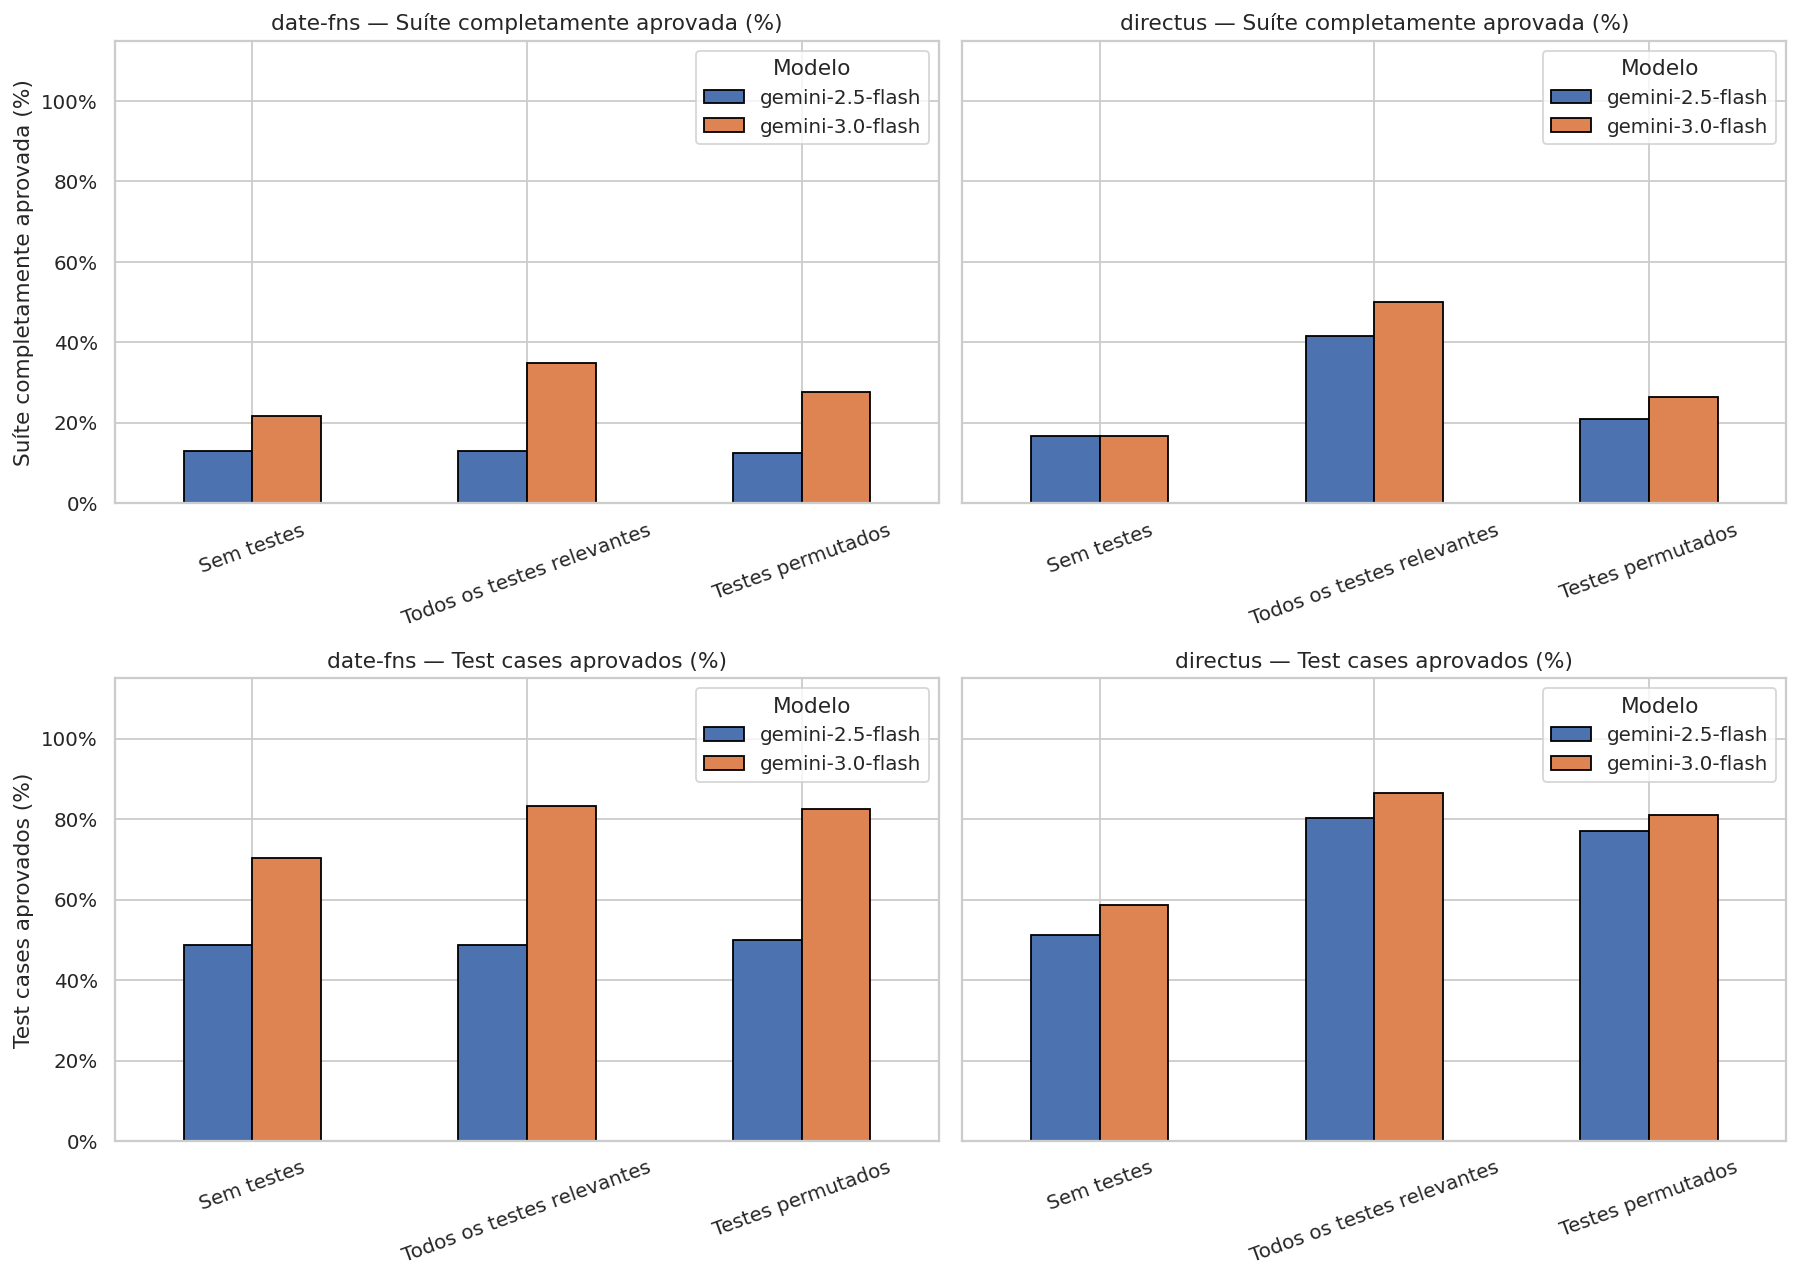

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

for row, (metric_col, metric_label) in enumerate(METRICS):
    for col, repo in enumerate(df["repositoryName"].dropna().unique()):
        ax = axes[row][col]
        subset = df[df["repositoryName"] == repo]
        rates = (
            subset.groupby(["contextType", "model"])[metric_col]
            .mean()
            .unstack("model")
            .reindex([c for c in CONTEXT_ORDER if c in subset["contextType"].unique()])
        )
        rates.index = [CONTEXT_LABELS.get(i, i) for i in rates.index]
        rates = rates * 100
        rates.plot(kind="bar", ax=ax, edgecolor="black")
        ax.set_title(f"{repo} — {metric_label}")
        ax.set_ylabel(metric_label)
        ax.set_ylim(0, 115)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.tick_params(axis="x", rotation=20)
        ax.legend(title="Modelo")

plt.tight_layout()
plt.savefig("success_by_context_model.png", bbox_inches="tight")
plt.show()

### Suíte completamente aprovada por método, contexto e modelo

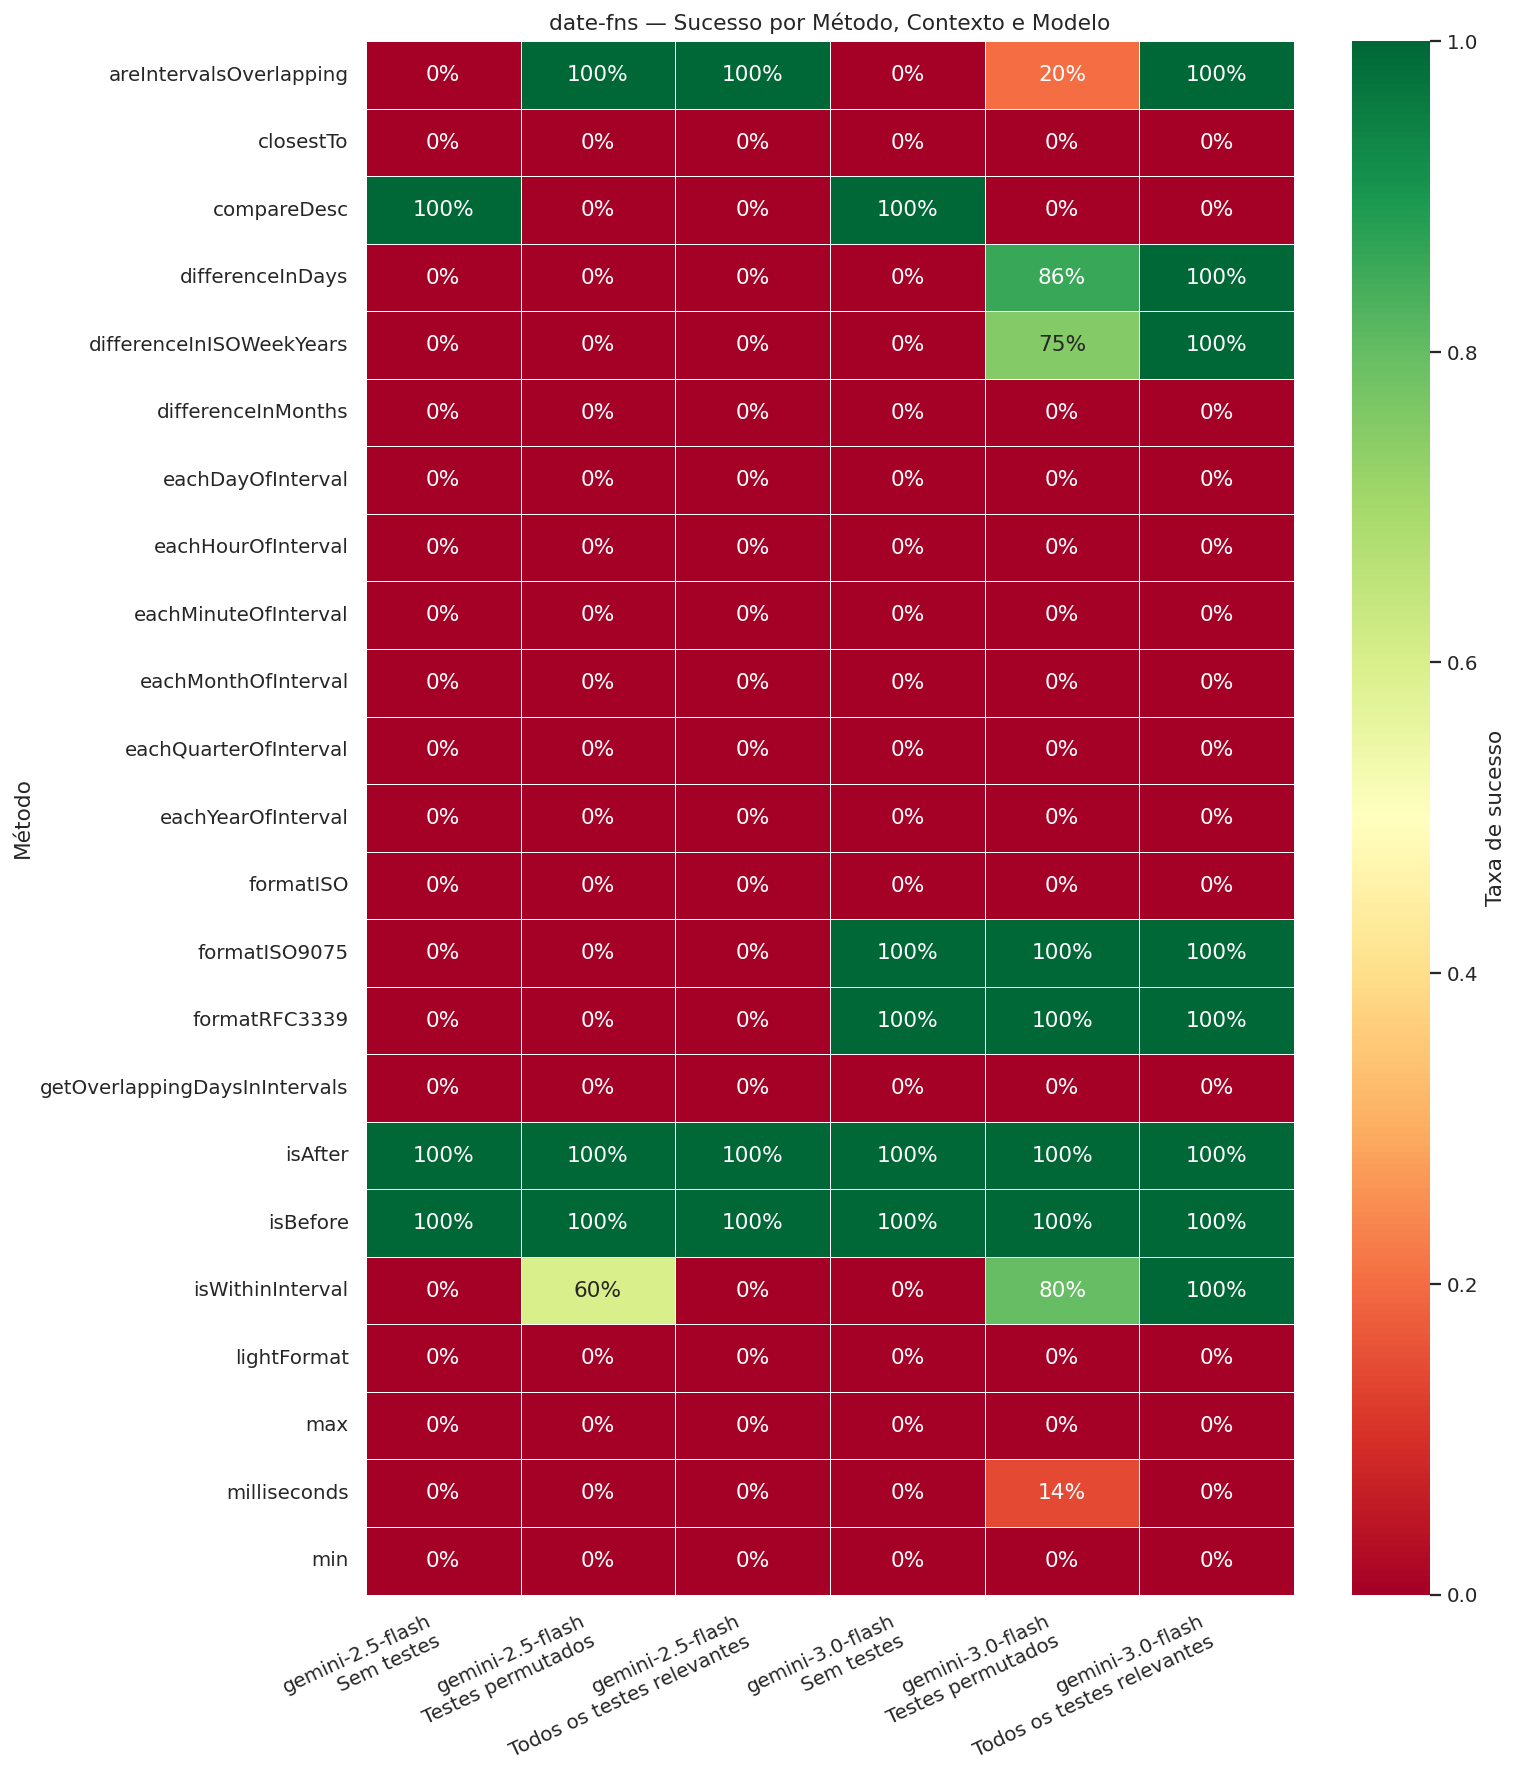

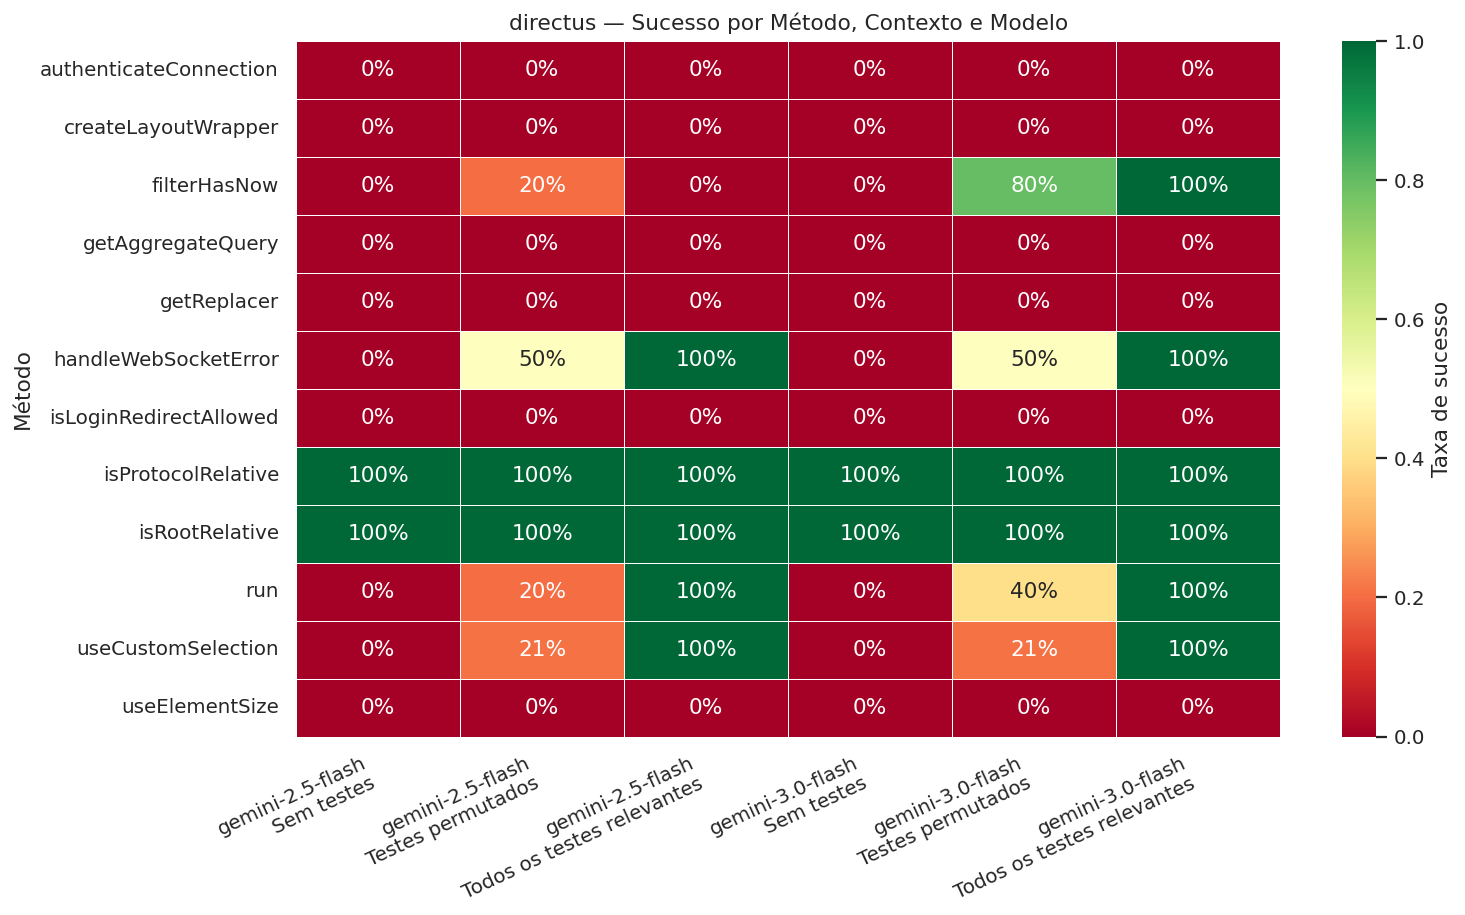

In [9]:
for repo in df["repositoryName"].dropna().unique():
    pivot = (
        df[df["repositoryName"] == repo]
        .groupby(["methodName", "contextType", "model"])["isTestSuiteSuccessful"]
        .mean()
        .reset_index()
        .assign(col=lambda d: d["model"] + "\n" + d["contextType"].map(CONTEXT_LABELS).fillna(d["contextType"]))
        .pivot(index="methodName", columns="col", values="isTestSuiteSuccessful")
        .fillna(np.nan)
    )
    plt.figure(figsize=(max(8, len(pivot.columns) * 2), max(4, len(pivot) * 0.6)))
    sns.heatmap(pivot, annot=True, fmt=".0%", cmap="RdYlGn",
                vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={"label": "Taxa de sucesso"})
    plt.title(f"{repo} — Sucesso por Método, Contexto e Modelo")
    plt.xlabel("")
    plt.ylabel("Método")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(f"heatmap_method_{repo}.png", bbox_inches="tight")
    plt.show()

### Compilabilidade por tipo de contexto e modelo

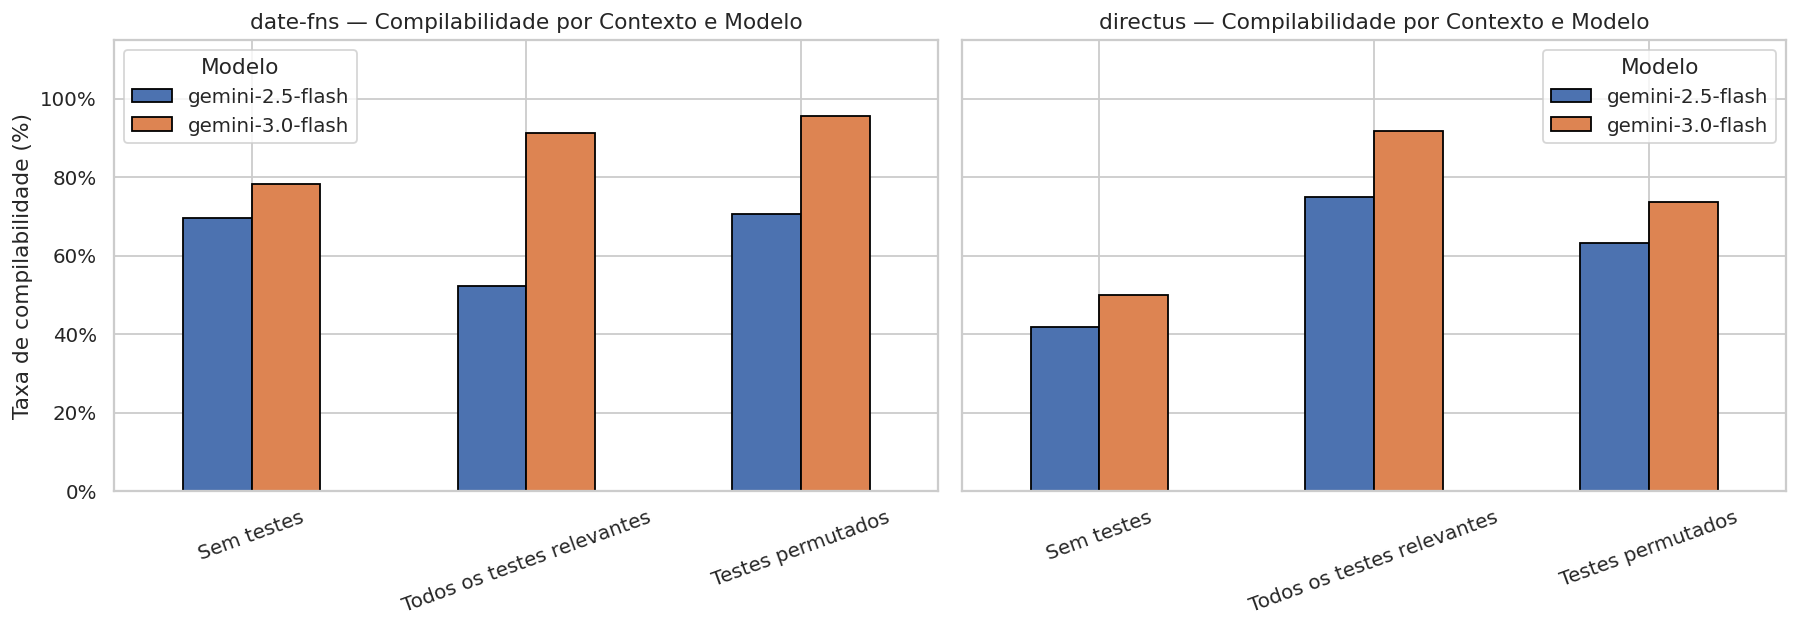

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, repo in zip(axes, df["repositoryName"].dropna().unique()):
    subset = df[df["repositoryName"] == repo]
    rates = (
        subset.groupby(["contextType", "model"])["isModelResultCompilable"]
        .mean()
        .unstack("model")
        .reindex([c for c in CONTEXT_ORDER if c in subset["contextType"].unique()])
    )
    rates.index = [CONTEXT_LABELS.get(i, i) for i in rates.index]
    rates = rates * 100
    rates.plot(kind="bar", ax=ax, edgecolor="black")
    ax.set_title(f"{repo} — Compilabilidade por Contexto e Modelo")
    ax.set_ylabel("Taxa de compilabilidade (%)")
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Modelo")

plt.tight_layout()
plt.savefig("compilable_by_context_model.png", bbox_inches="tight")
plt.show()

### Impacto do número de testes relevantes no pass rate

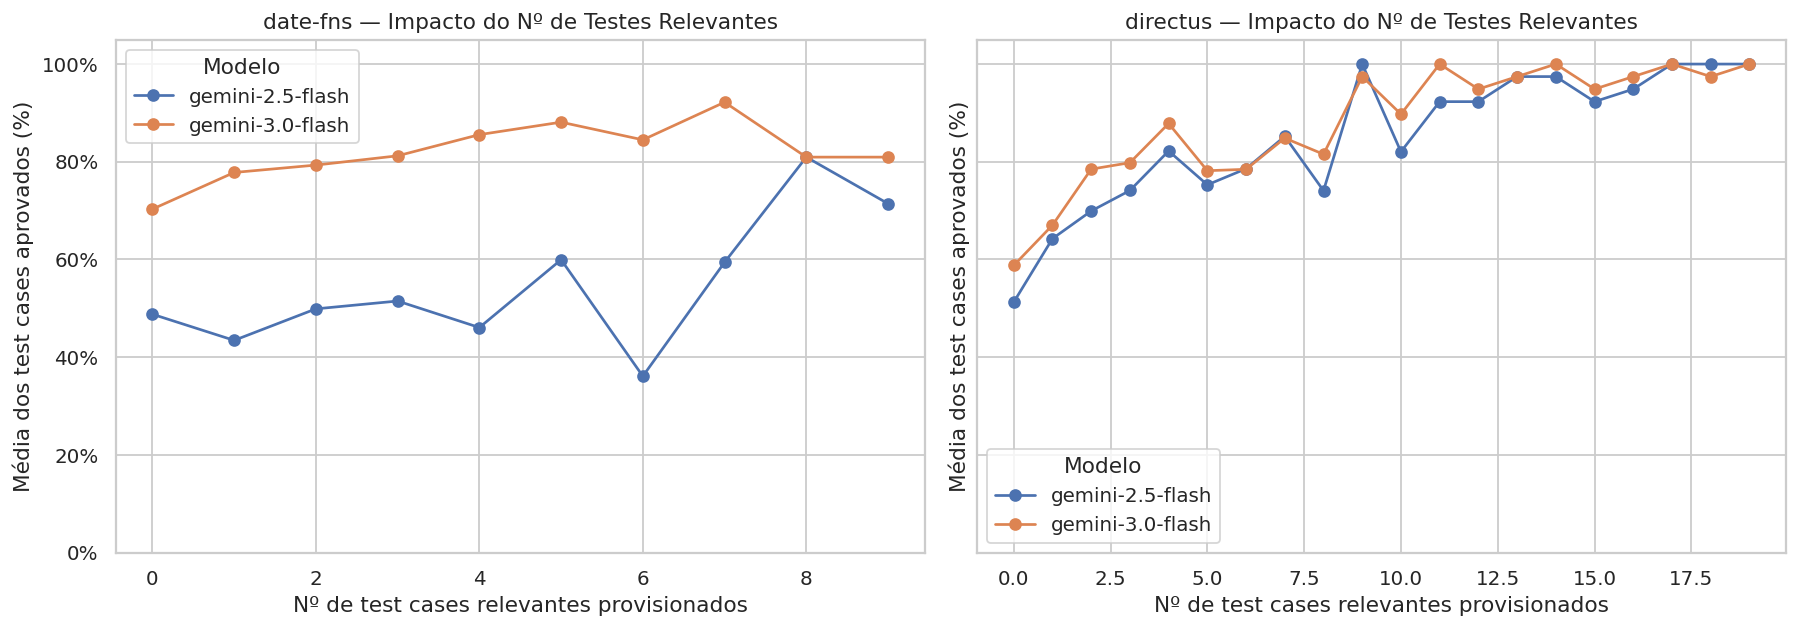

In [11]:
impact = (
    df.assign(testCasePassRateClamped=df["testCasePassRate"].clip(0, 1))
    .groupby(["repositoryName", "relevantTestCaseCount", "model"])["testCasePassRateClamped"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, repo in zip(axes, df["repositoryName"].dropna().unique()):
    d = impact[impact["repositoryName"] == repo]
    for model_name, group in d.groupby("model"):
        group = group.sort_values("relevantTestCaseCount")
        ax.plot(group["relevantTestCaseCount"], group["testCasePassRateClamped"] * 100,
                marker="o", label=model_name)
    ax.set_title(f"{repo} — Impacto do Nº de Testes Relevantes")
    ax.set_xlabel("Nº de test cases relevantes provisionados")
    ax.set_ylabel("Média dos test cases aprovados (%)")
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title="Modelo")

plt.tight_layout()
plt.savefig("impact_relevant_test_count.png", bbox_inches="tight")
plt.show()

## Análise em Linguagem Natural

### Setup do Agente

In [12]:
import os
from dotenv import load_dotenv
from google import genai
from pandasai import Agent
from pandasai.llm.base import LLM

load_dotenv("../.env")

class GoogleGenAILLM(LLM):
    def __init__(self, model: str, api_key: str):
        self.model = model
        self._client = genai.Client(api_key=api_key)

    def call(self, instruction, context=None):
        self.last_prompt = instruction.to_string()
        response = self._client.models.generate_content(
            model=self.model,
            contents=self.last_prompt,
        )
        return response.text

    @property
    def type(self) -> str:
        return "google-genai"

llm = GoogleGenAILLM(model="gemini-3-flash-preview", api_key=os.environ["GOOGLE_GENERATIVE_AI_API_KEY"])
agent = Agent([df], config={"llm": llm, "verbose": False, "custom_whitelisted_dependencies": ["os"], "open_charts": False})

In [13]:
from IPython.display import display, Markdown, Image
import os

def show_agent_result(result):
    if isinstance(result, str) and os.path.isfile(result):
        display(Image(filename=result))
    elif isinstance(result, str):
        display(Markdown(result))
    else:
        display(result)


### Perguntas para o Agente

In [14]:
questions = [
    # "Quais métodos foram reconstruídos com sucesso em todos os contextos testados?",
    # "Quais métodos nunca foram reconstruídos com sucesso, independente do contexto ou modelo?",
    # "Resuma os principais achados do experimento em tópicos.",
    # "Existe algum padrão claro que indique quando o contexto de testes ajuda e quando não ajuda?"
]

for question in questions:
    display(Markdown(f"---\n### {question}"))
    show_agent_result(agent.chat(question))

# 5. Perguntas de Pesquisa

## RQ1: Qual a relevância dos testes de unidade para geração de métodos?

### Gráfico: Taxa de sucesso/aprovação x Quantidade de testes no contexto

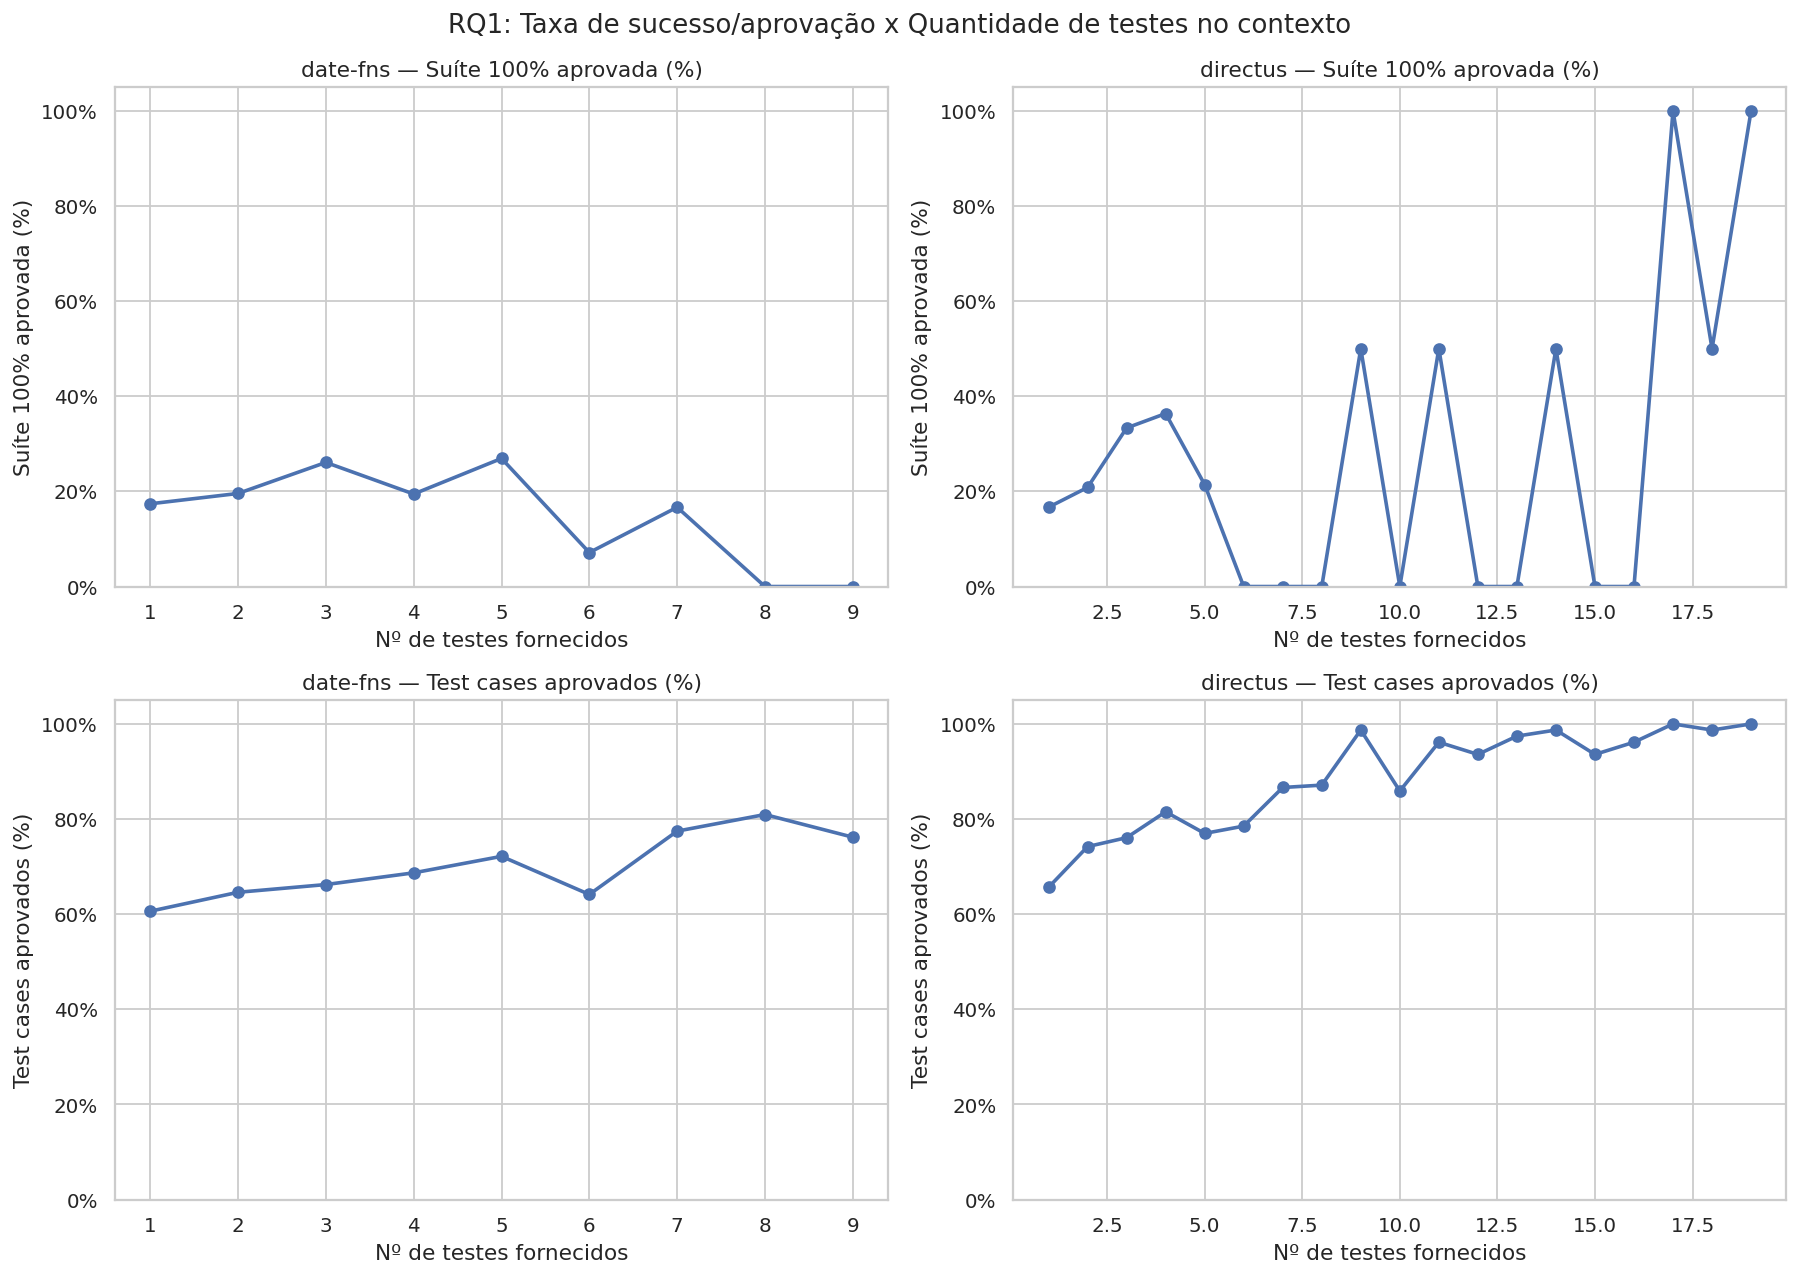

In [15]:
permuted = df[df["contextType"] == "permuted-relevant-test-case"].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col_idx, (metric_col, metric_label) in enumerate([
    ("isTestSuiteSuccessful", "Suíte 100% aprovada (%)"),
    ("testCasePassRate",      "Test cases aprovados (%)"),
]):
    impact = (
        permuted.groupby(["repositoryName", "experimentContextItemCount"])[metric_col]
        .agg(["mean", "sem"])
        .reset_index()
    )

    for row_idx, repo in enumerate(df["repositoryName"].unique()):
        ax = axes[col_idx][row_idx]

        d = impact[impact["repositoryName"] == repo].sort_values("experimentContextItemCount")
        ax.plot(d["experimentContextItemCount"], d["mean"] * 100, marker="o", linewidth=2, label="Média")

        ax.set_title(f"{repo} — {metric_label}")
        ax.set_xlabel("Nº de testes fornecidos")
        ax.set_ylabel(metric_label)
        ax.set_ylim(0, 105)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle("RQ1: Taxa de sucesso/aprovação x Quantidade de testes no contexto")
plt.tight_layout()
plt.savefig("figures/rq1_test_count_vs_success.png", bbox_inches="tight")
plt.show()

### Gráfico: Taxa de aprovação por método × Quantidade de testes no contexto

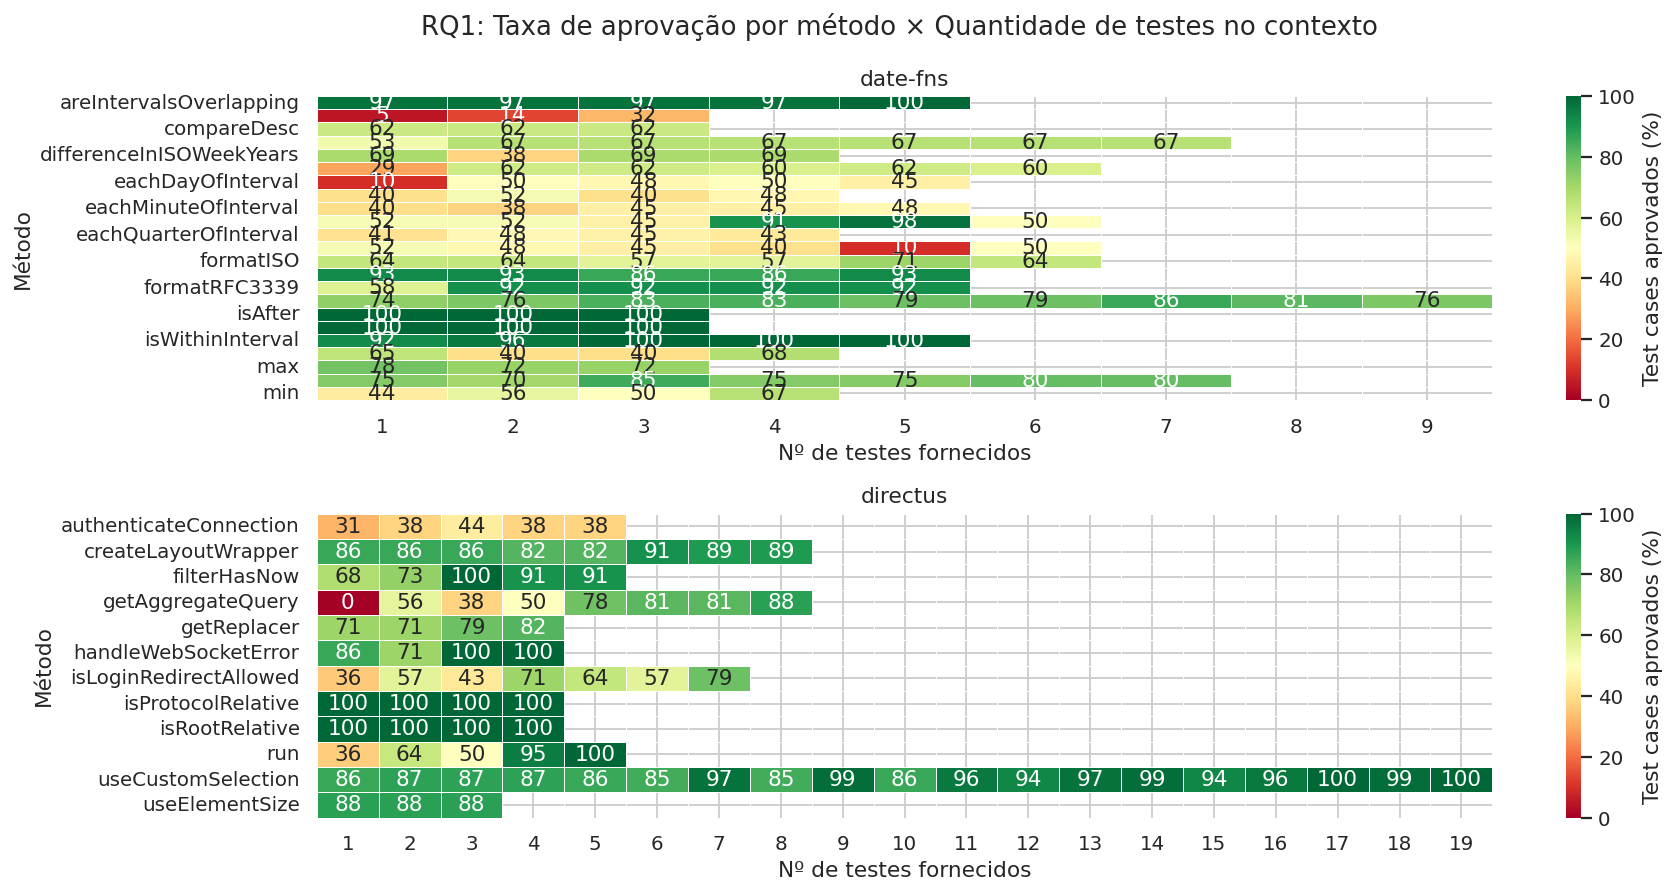

In [16]:
permuted = df[df["contextType"] == "permuted-relevant-test-case"].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax, repo in zip(axes, permuted["repositoryName"].unique()):
    d = permuted[permuted["repositoryName"] == repo]
    pivot = (
        d.groupby(["methodName", "experimentContextItemCount"])["testCasePassRate"]
        .mean()
        .unstack("experimentContextItemCount")
        .sort_index()
    )
    sns.heatmap(pivot * 100, ax=ax, cmap="RdYlGn", vmin=0, vmax=100,
                annot=True, fmt=".0f", linewidths=0.3,
                cbar_kws={"label": "Test cases aprovados (%)"})
    ax.set_title(f"{repo}")
    ax.set_xlabel("Nº de testes fornecidos")
    ax.set_ylabel("Método")

plt.suptitle("RQ1: Taxa de aprovação por método × Quantidade de testes no contexto")
plt.tight_layout()
plt.savefig("figures/rq1_method_heatmap.png", bbox_inches="tight")
plt.show()

## RQ2: Quais tipos de testes contribuem mais?

### Gráfico: Taxa de aprovação x Tipo de estrutura do teste

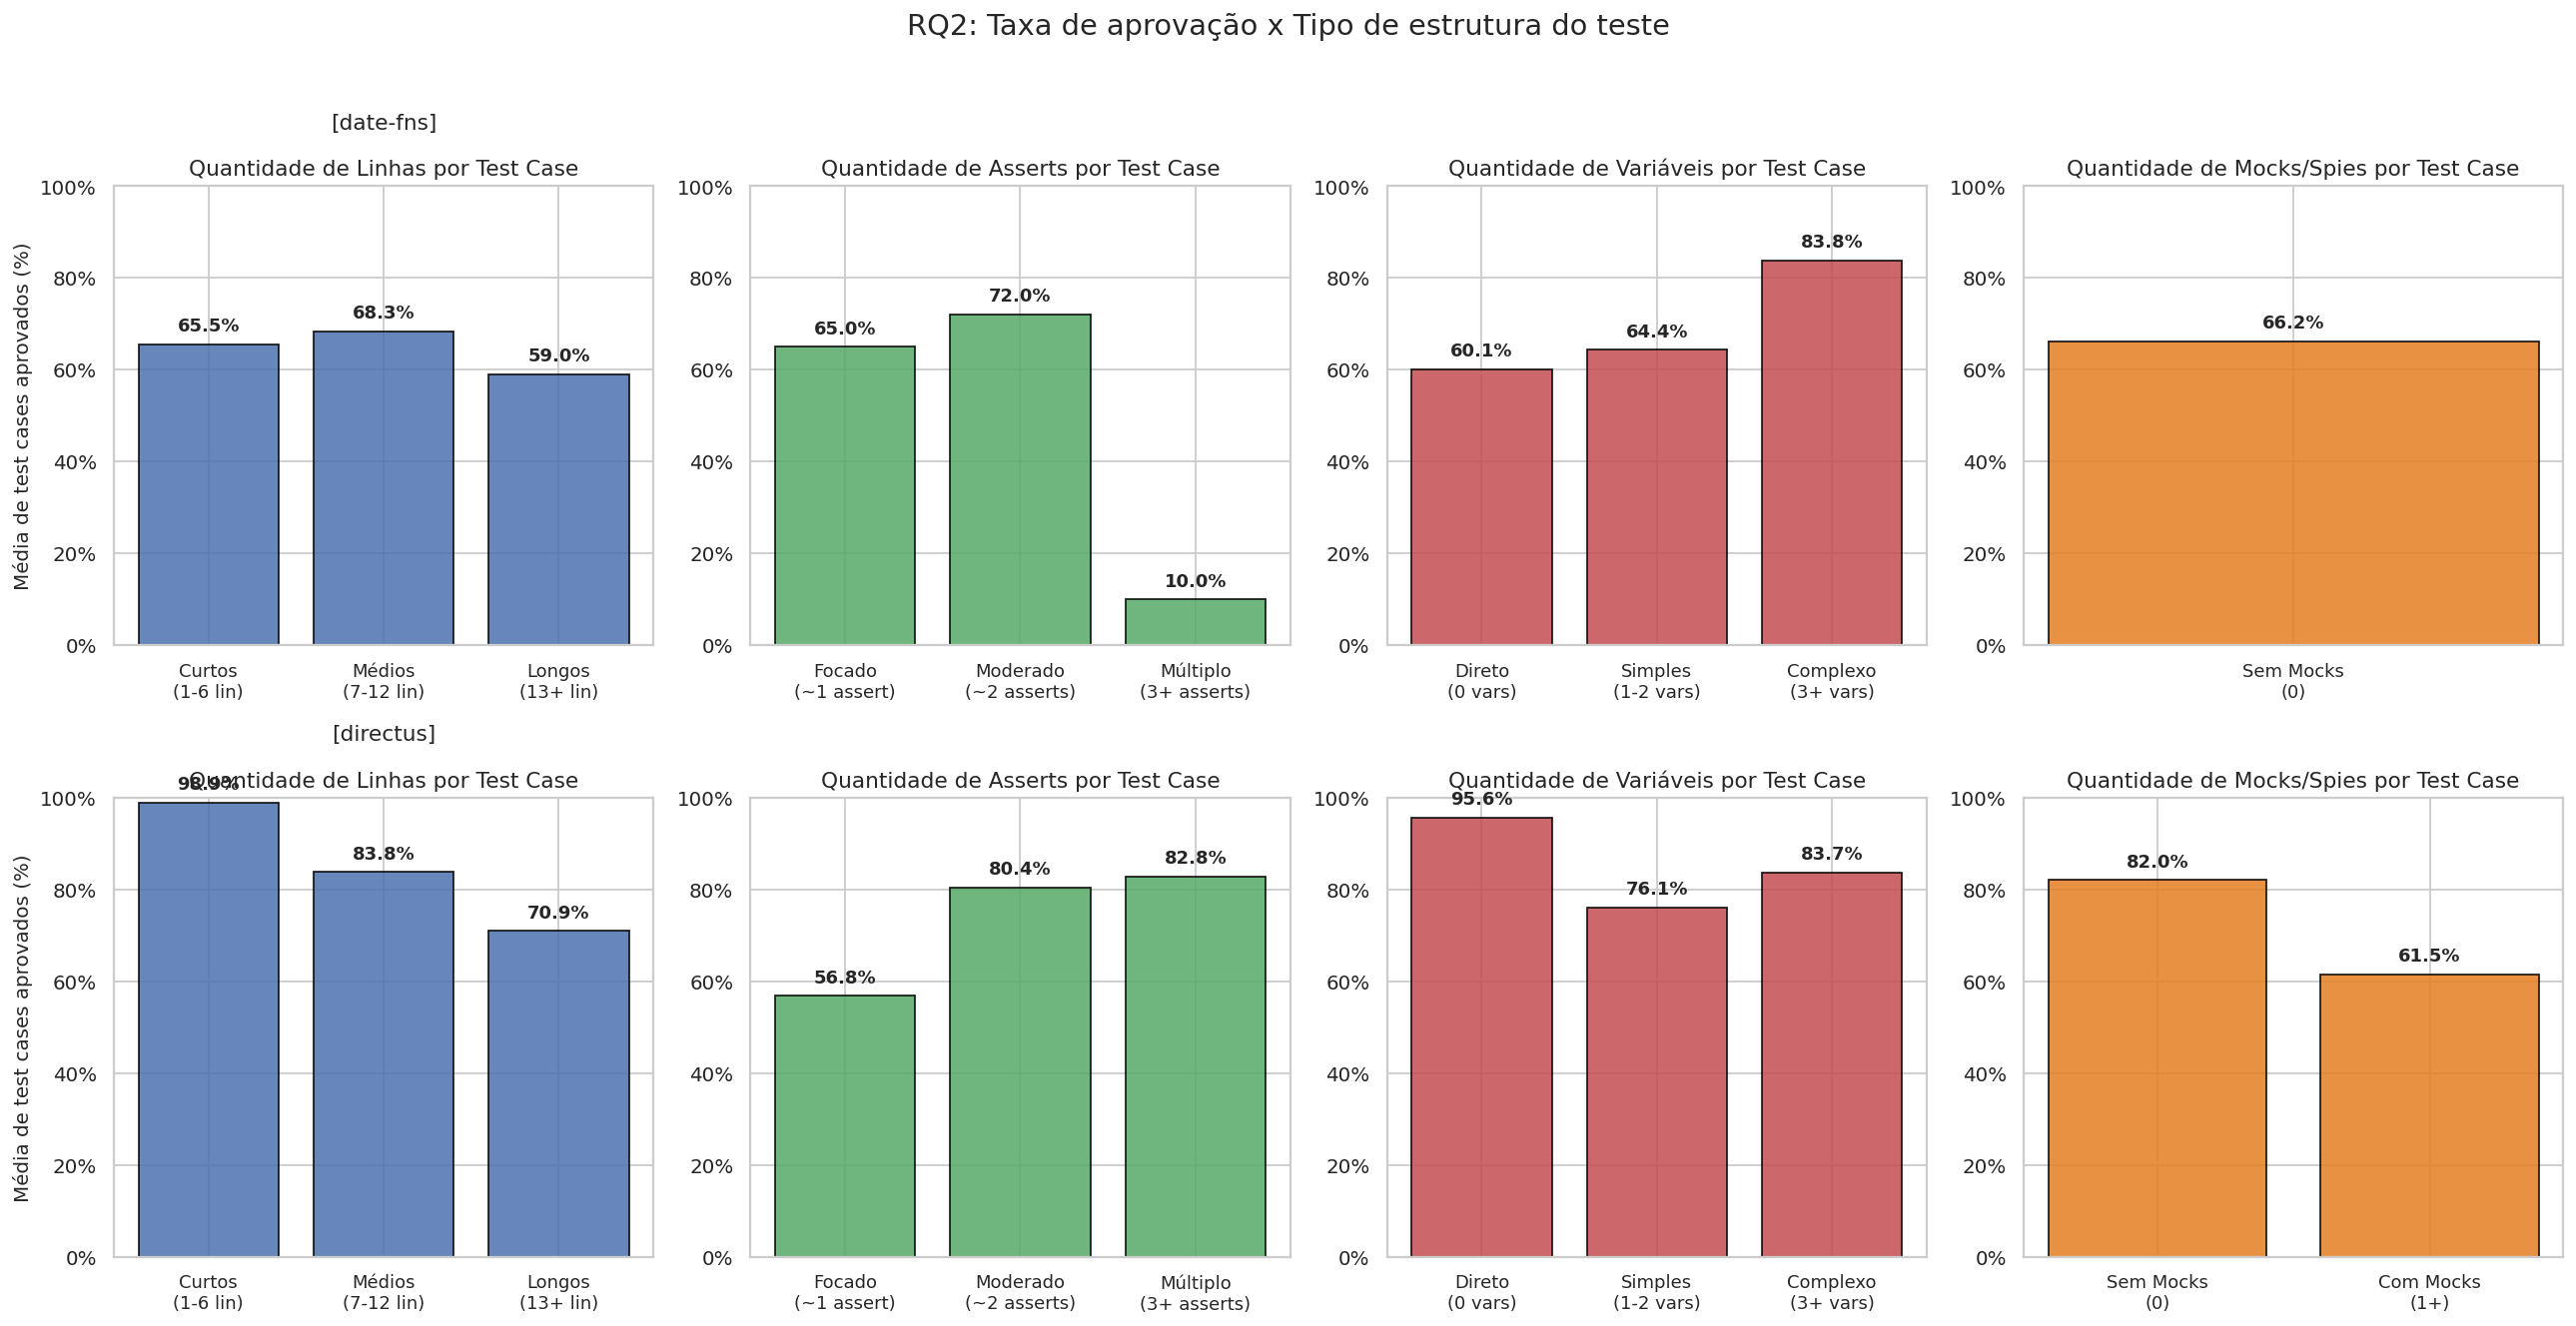

In [17]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

def extract_structural_metrics(prompt_json):
    try:
        prompt = json.loads(prompt_json)
    except Exception:
        prompt = prompt_json
        
    text = prompt if isinstance(prompt, str) else str(prompt)
    
    test_blocks = re.findall(r"## relevant-test-case.*?```\w*\n(.*?)```", text, re.DOTALL)
    
    if not test_blocks:
        return {"avg_lines": 0, "avg_assertions": 0, "avg_vars": 0, "avg_mocks": 0}
    
    lines_per_block = [block.strip().count("\n") + 1 for block in test_blocks]
    assertions_per_block = [len(re.findall(r"\bexpect\(|\bassert\b|\bshould\b", block)) for block in test_blocks]
    vars_per_block = [len(re.findall(r"\bconst\b|\blet\b|\bvar\b", block)) for block in test_blocks]
    mocks_per_block = [len(re.findall(r"\bjest\b|\bvi\b|\bmock\b|\bspyOn\b", block)) for block in test_blocks]
    
    return {
        "avg_lines": np.mean(lines_per_block),
        "avg_assertions": np.mean(assertions_per_block),
        "avg_vars": np.mean(vars_per_block),
        "avg_mocks": np.mean(mocks_per_block)
    }

metrics_df = df[df["contextType"] == "permuted-relevant-test-case"].copy()
metrics_df = metrics_df.reset_index(drop=True)

extracted = metrics_df["modelUserPrompt"].apply(extract_structural_metrics)
metrics_df = metrics_df.join(pd.DataFrame(extracted.tolist()))

metrics_df['cat_linhas'] = pd.cut(
    metrics_df['avg_lines'], 
    bins=[0, 6, 12, 100], 
    labels=['Curtos\n(1-6 lin)', 'Médios\n(7-12 lin)', 'Longos\n(13+ lin)']
)

metrics_df['cat_assertions'] = pd.cut(
    metrics_df['avg_assertions'], 
    bins=[0, 1.2, 2.5, 100], 
    labels=['Focado\n(~1 assert)', 'Moderado\n(~2 asserts)', 'Múltiplo\n(3+ asserts)']
)

metrics_df['cat_vars'] = pd.cut(
    metrics_df['avg_vars'], 
    bins=[-1, 0.5, 2.5, 100], 
    labels=['Direto\n(0 vars)', 'Simples\n(1-2 vars)', 'Complexo\n(3+ vars)']
)

metrics_df['cat_mocks'] = pd.cut(
    metrics_df['avg_mocks'], 
    bins=[-1, 0.5, 100], 
    labels=['Sem Mocks\n(0)', 'Com Mocks\n(1+)']
)

repos = metrics_df["repositoryName"].unique()

configs = [
    {'col': 'cat_linhas', 'title': 'Quantidade de Linhas por Test Case', 'color': '#4C72B0'},
    {'col': 'cat_assertions', 'title': 'Quantidade de Asserts por Test Case', 'color': '#55A868'},
    {'col': 'cat_vars', 'title': 'Quantidade de Variáveis por Test Case', 'color': '#C44E52'},
    {'col': 'cat_mocks', 'title': 'Quantidade de Mocks/Spies por Test Case', 'color': '#E67E22'}
]

fig, axes = plt.subplots(len(repos), len(configs), figsize=(20, 5 * len(repos)))

if len(repos) == 1:
    axes = [axes]

for row_idx, repo in enumerate(repos):
    d = metrics_df[metrics_df["repositoryName"] == repo]
    
    for col_idx, config in enumerate(configs):
        ax = axes[row_idx][col_idx]
        
        media = d.groupby(config['col'], observed=False)['testCasePassRate'].mean() * 100
        
        bars = ax.bar(media.index, media.values, color=config['color'], edgecolor='black', alpha=0.85)

        repo_title = f"[{repo}]\n\n" if col_idx == 0 else ""
        ax.set_title(f"{repo_title}{config['title']}", fontsize=12)
        
        if col_idx == 0:
            ax.set_ylabel("Média de test cases aprovados (%)", fontsize=11)
            
        ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.tick_params(axis='x', labelsize=10)
        
        for bar in bars:
            yval = bar.get_height()
            if not np.isnan(yval) and yval > 0:
                ax.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", 
                        ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle("RQ2: Taxa de aprovação x Tipo de estrutura do teste", fontsize=16, y=1.05 if len(repos)==1 else 1.02)
plt.tight_layout()
plt.savefig("figures/rq2_internal_structure_analysis.png", bbox_inches="tight")
plt.show()

## RQ3: Quais LLMs geram métodos de forma mais eficiente?

### Gráfico: Taxa de sucesso por modelo x Tipo de contexto

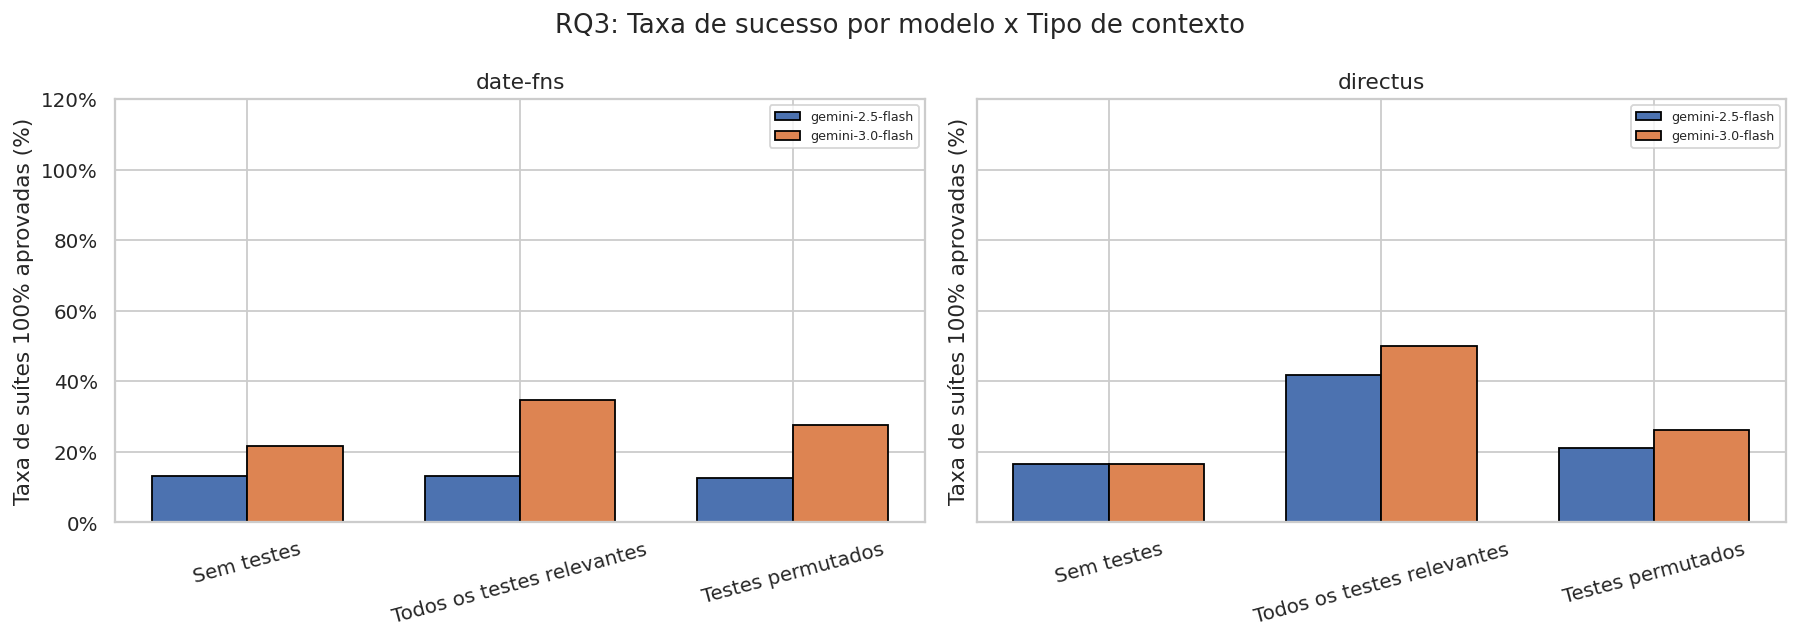

In [18]:
rates = (
    df.groupby(["repositoryName", "modelName", "contextType"])["isTestSuiteSuccessful"]
    .agg(["mean", "count"])
    .reset_index()
)
global_rates = df.groupby("modelName")["isTestSuiteSuccessful"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, repo in zip(axes, df["repositoryName"].unique()):
    d = rates[rates["repositoryName"] == repo]
    ordered  = [c for c in CONTEXT_ORDER if c in d["contextType"].values]
    models   = d["modelName"].unique()
    x        = np.arange(len(ordered))
    width    = 0.35

    for i, model in enumerate(models):
        dm   = d[d["modelName"] == model].set_index("contextType").reindex(ordered, fill_value=0)
        bars = ax.bar(x + i * width, dm["mean"] * 100, width, label=model, edgecolor="black")

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([CONTEXT_LABELS.get(c, c) for c in ordered], rotation=15)
    ax.set_title(f"{repo}")
    ax.set_ylabel("Taxa de suítes 100% aprovadas (%)")
    ax.set_ylim(0, 120)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=7)

plt.suptitle("RQ3: Taxa de sucesso por modelo x Tipo de contexto")
plt.tight_layout()
plt.savefig("figures/rq3_model_vs_context.png", bbox_inches="tight")
plt.show()

### Gráfico: Taxa de compilabilidade por modelo

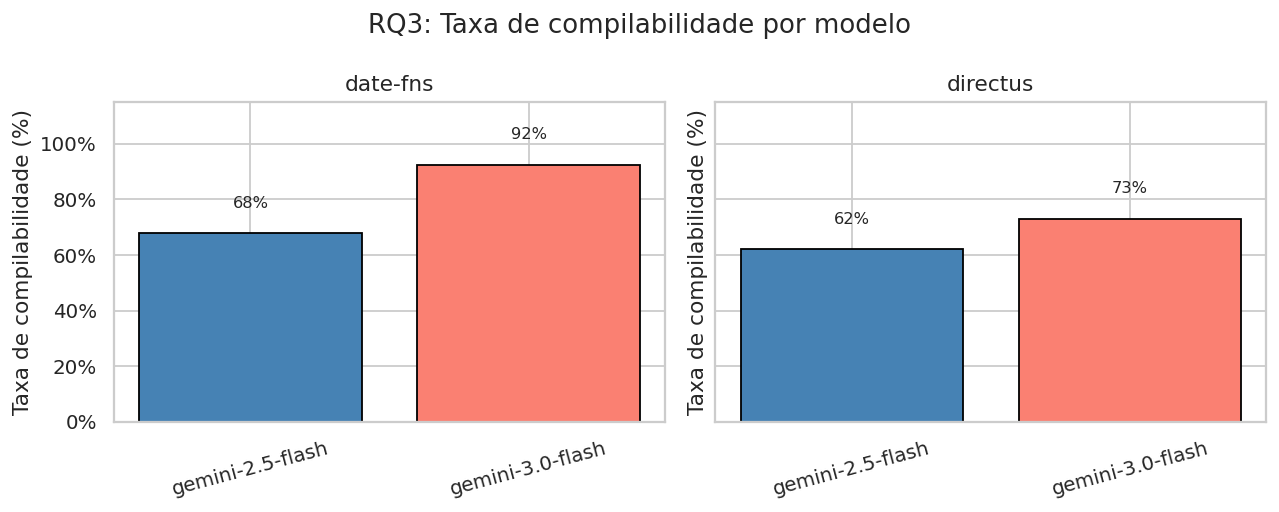

In [19]:
from scipy.stats import norm as _norm

def wilson_ci(successes, n, confidence=0.95):
    z = _norm.ppf((1 + confidence) / 2)
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return center - margin, center + margin

comp = (
    df.groupby(["repositoryName", "modelName"])["isModelResultCompilable"]
    .agg(["sum", "count"])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, repo in zip(axes, comp["repositoryName"].unique()):
    d = comp[comp["repositoryName"] == repo]
    means     = d["sum"] / d["count"]
    ci_bounds = [wilson_ci(s, n) for s, n in zip(d["sum"], d["count"])]
    yerr_low  = means - np.array([b[0] for b in ci_bounds])
    yerr_high = np.array([b[1] for b in ci_bounds]) - means

    bars = ax.bar(d["modelName"], means * 100, edgecolor="black", capsize=5, color=["steelblue", "salmon"])
    for bar, val, n in zip(bars, means, d["count"]):
        ax.annotate(f"{val*100:.0f}%\n",
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2),
                    ha="center", va="bottom", fontsize=9)

    ax.set_title(f"{repo}")
    ax.set_ylabel("Taxa de compilabilidade (%)")
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("RQ3: Taxa de compilabilidade por modelo")
plt.tight_layout()
plt.savefig("figures/rq3_compilability_by_model.png", bbox_inches="tight")
plt.show()

### Gráfico: Comparação de modelo pareada da taxa de aprovação dos testes por método

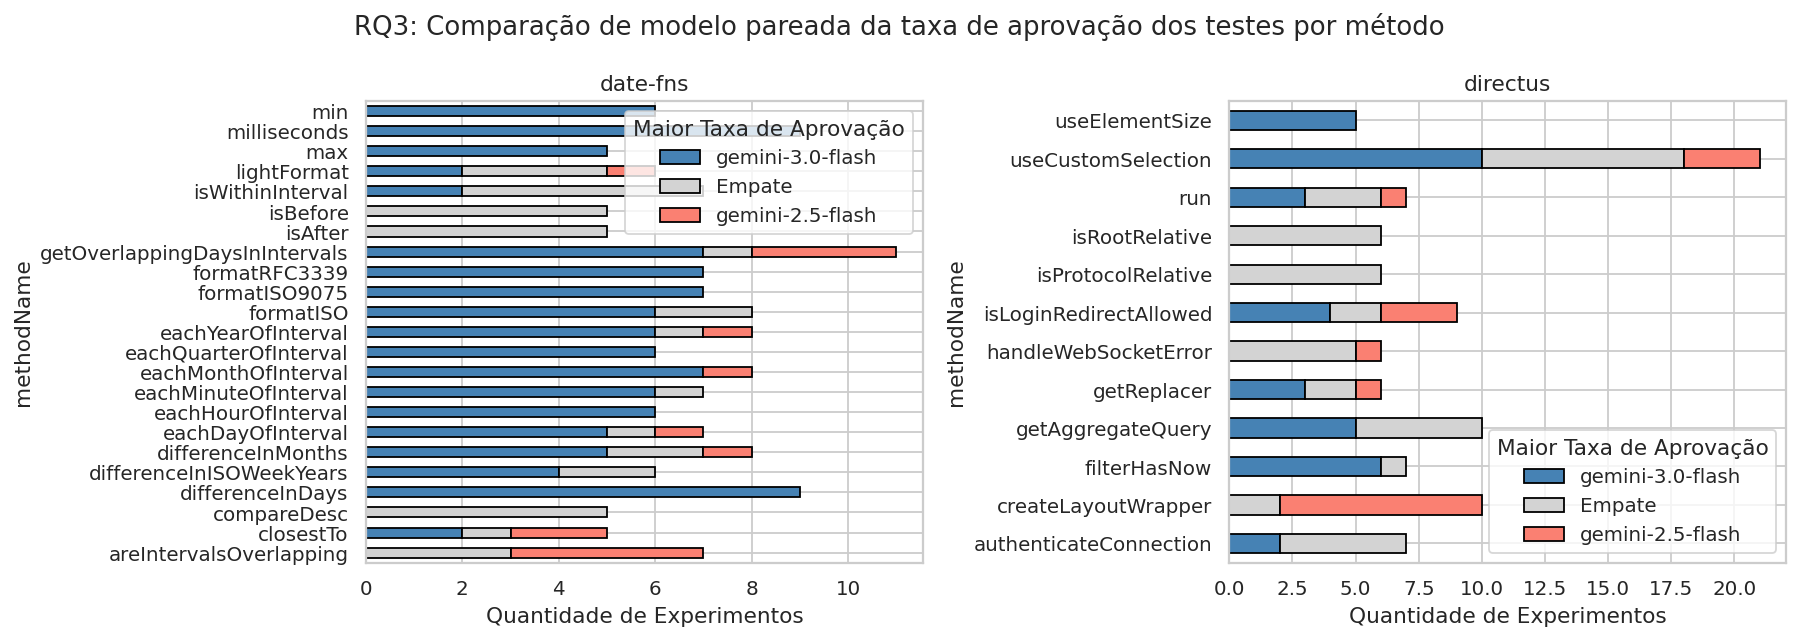

In [20]:
models = df["modelName"].unique()
if len(models) != 2:
    print("Essa análise requer exatamente 2 modelos no dataset.")
else:
    m0, m1 = models[0], models[1]

    left  = df[df["modelName"] == m0][["repositoryName", "methodName", "contextType",
                                        "experimentContextItemCount", "testCasePassRate"]]
    right = df[df["modelName"] == m1][["repositoryName", "methodName", "contextType",
                                        "experimentContextItemCount", "testCasePassRate"]]
    paired = left.merge(right,
                        on=["repositoryName", "methodName", "contextType", "experimentContextItemCount"],
                        suffixes=(f"_{m0}", f"_{m1}"))

    def outcome(row):
        a = row[f"testCasePassRate_{m0}"]
        b = row[f"testCasePassRate_{m1}"]
    
        if abs(a - b) < 0.01:
            return "Empate"
    
        return (
            f"{m1}"
            if b > a
            else f"{m0}"
        )
    
    paired["outcome"] = paired.apply(outcome, axis=1)
    
    summary = (
        paired.groupby(["repositoryName", "methodName", "outcome"])
        .size()
        .unstack("outcome", fill_value=0)
        .reset_index()
    )
    
    outcome_order = [
        f"{m1}",
        "Empate",
        f"{m0}"
    ]
    
    outcome_colors = {
        "Empate": "lightgray",
        f"{m1}": "steelblue",
        f"{m0}": "salmon"
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, repo in zip(axes, summary["repositoryName"].unique()):
        d     = summary[summary["repositoryName"] == repo].set_index("methodName")
        cols  = [c for c in outcome_order if c in d.columns]
        colors = [outcome_colors[c] for c in cols]
        d[cols].plot(kind="barh", stacked=True, ax=ax, color=colors, edgecolor="black")
        ax.set_title(f"{repo}")
        ax.set_xlabel("Quantidade de Experimentos")
        ax.legend(title="Maior Taxa de Aprovação")

    plt.suptitle(f"RQ3: Comparação de modelo pareada da taxa de aprovação dos testes por método")
    plt.tight_layout()
    plt.savefig("figures/rq3_win_loss_by_method.png", bbox_inches="tight")
    plt.show()

# 6. Perguntas de Pesquisa (Gráficos atualizados)

## RQ1: Qual a relevância dos testes de unidade para geração de métodos?

### Gráfico: Distribuição da taxa de sucesso/aprovação × Quantidade de testes no contexto

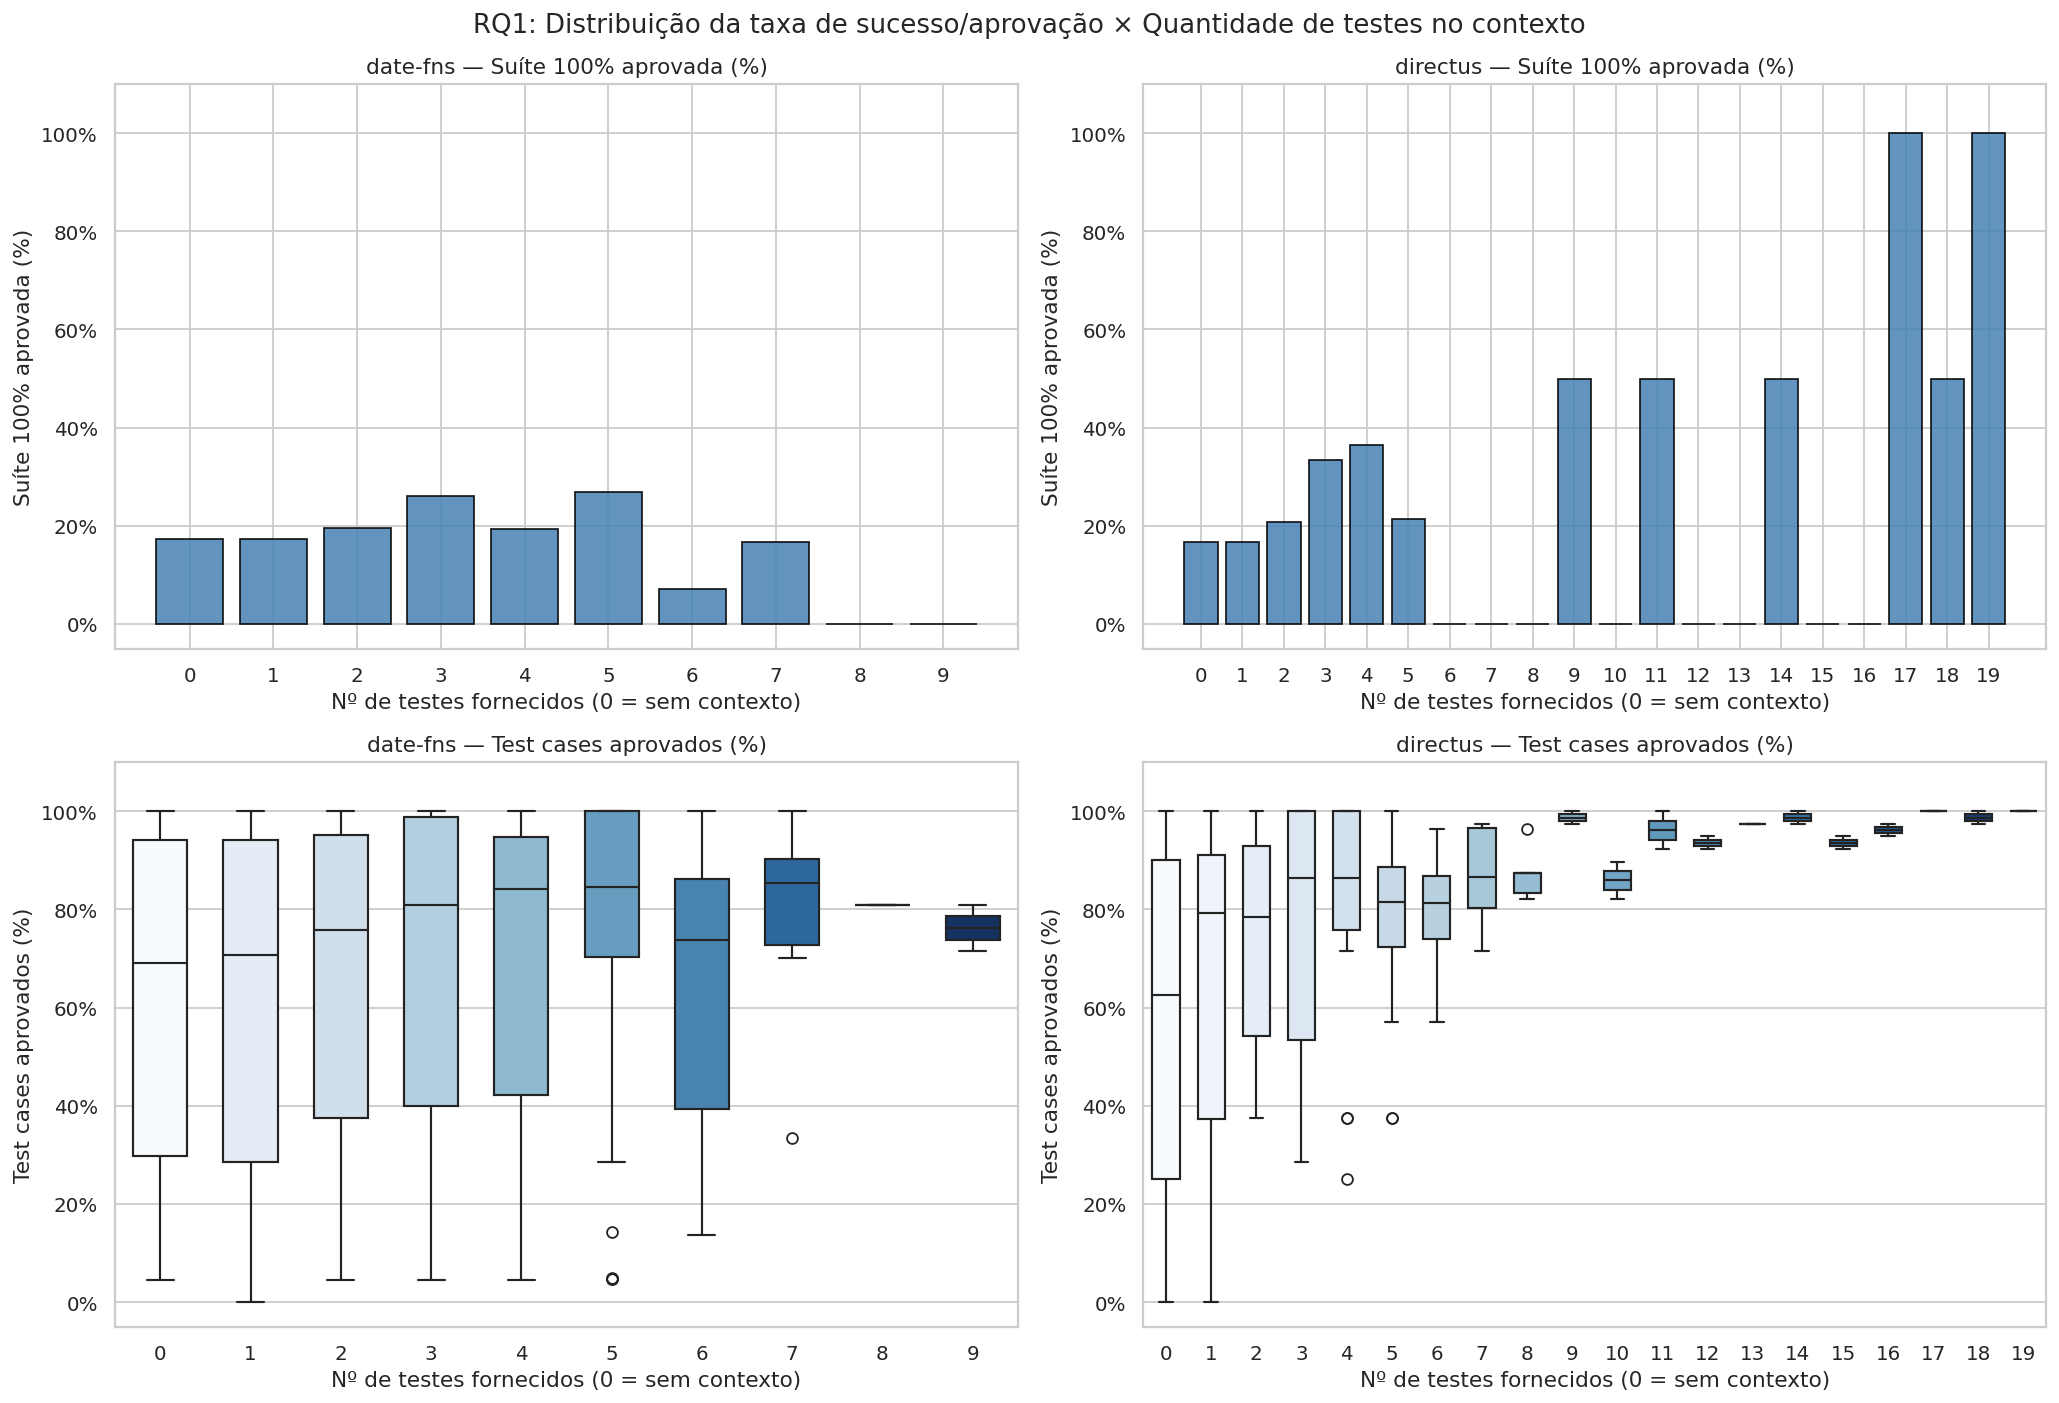

In [21]:
baseline_v2 = df[df["contextType"] == "no-relevant-test-case"].copy()
baseline_v2["experimentContextItemCount"] = 0

permuted_v2 = df[df["contextType"] == "permuted-relevant-test-case"].copy()
combined_v2 = pd.concat([baseline_v2, permuted_v2], ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for col_idx, (metric_col, metric_label) in enumerate([
    ("isTestSuiteSuccessful", "Suíte 100% aprovada (%)"),
    ("testCasePassRate",      "Test cases aprovados (%)"),
]):
    for row_idx, repo in enumerate(df["repositoryName"].unique()):
        ax = axes[col_idx][row_idx]
        d = combined_v2[combined_v2["repositoryName"] == repo].copy()
        d[metric_col] = d[metric_col].astype(float) * 100
        order = sorted(d["experimentContextItemCount"].unique())

        if metric_col == "isTestSuiteSuccessful":
            means = (
                d.groupby("experimentContextItemCount")[metric_col]
                .mean()
                .reindex(order)
            )
            ax.bar(
                [str(x) for x in means.index],
                means.values,
                edgecolor="black",
                color="steelblue",
                alpha=0.85,
            )
            ax.set_xlabel("Nº de testes fornecidos (0 = sem contexto)")
        else:
            sns.boxplot(
                data=d,
                x="experimentContextItemCount",
                y=metric_col,
                hue="experimentContextItemCount",
                order=order,
                ax=ax,
                palette="Blues",
                legend=False,
                width=0.6,
                linewidth=1.2,
            )
            ax.set_xlabel("Nº de testes fornecidos (0 = sem contexto)")

        ax.set_title(f"{repo} — {metric_label}")
        ax.set_ylabel(metric_label)
        ax.set_ylim(-5, 110)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle("RQ1: Distribuição da taxa de sucesso/aprovação × Quantidade de testes no contexto")
plt.tight_layout()
plt.savefig("figures/rq1_test_count_vs_success_v2.png", bbox_inches="tight")
plt.show()

### Gráfico: Delta de aprovação por método × Quantidade de testes

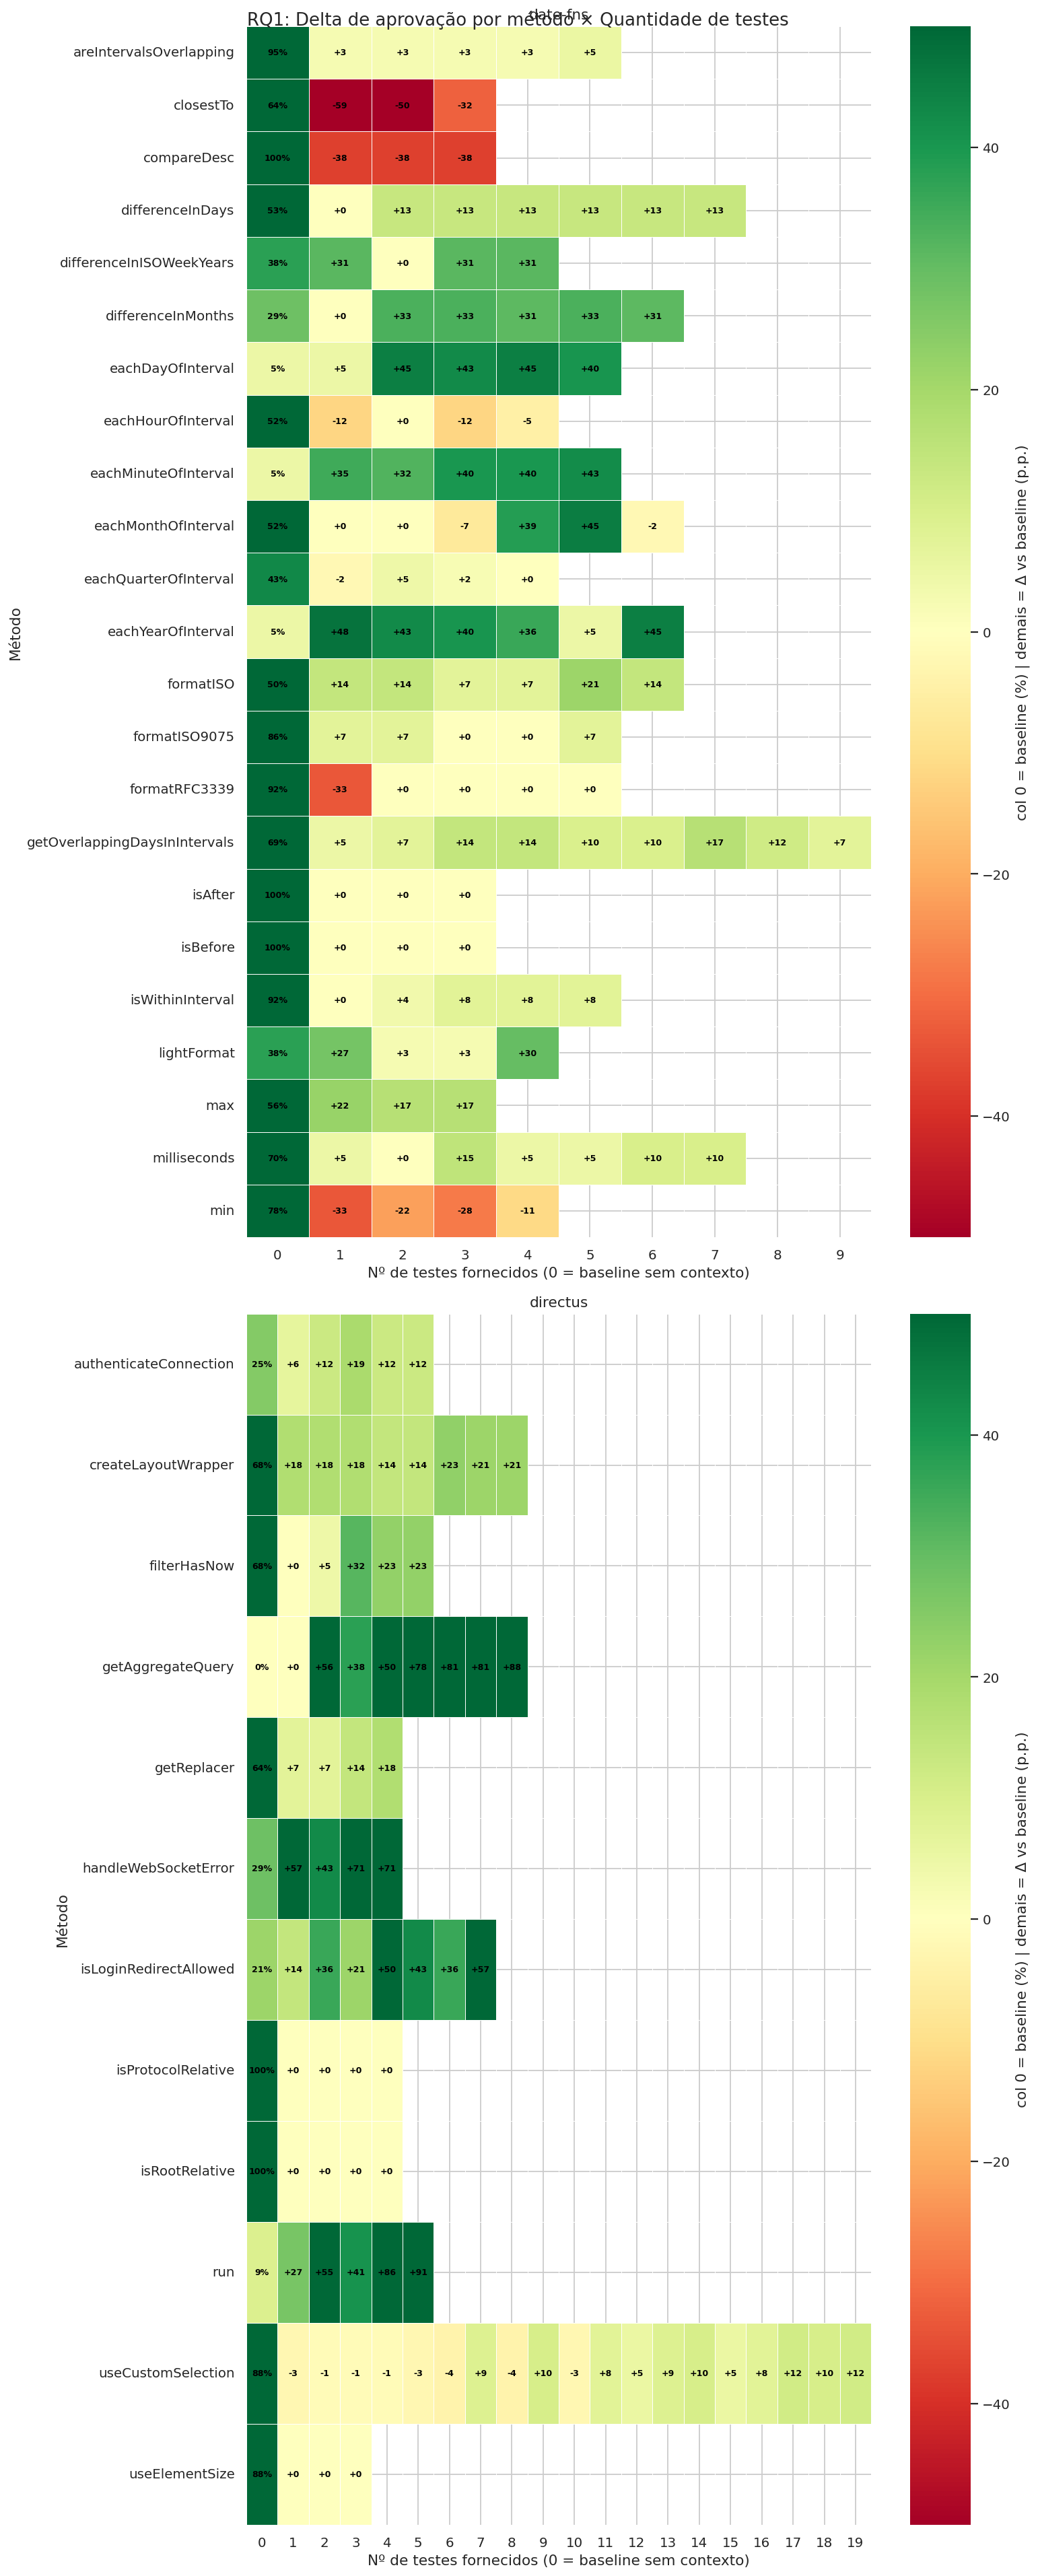

In [22]:
from matplotlib.colors import TwoSlopeNorm

baseline_no_ctx = df[df["contextType"] == "no-relevant-test-case"].copy()
baseline_no_ctx["experimentContextItemCount"] = 0
permuted_v2_heatmap = df[df["contextType"] == "permuted-relevant-test-case"].copy()
combined_heatmap = pd.concat([baseline_no_ctx, permuted_v2_heatmap], ignore_index=True)

# Subtração sempre em relação ao baseline (no-relevant-test-case), não ao caso anterior
baseline_per_method = (
    df[df["contextType"] == "no-relevant-test-case"]
    .groupby(["repositoryName", "methodName"])["testCasePassRate"]
    .mean()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 30))

for ax, repo in zip(axes, combined_heatmap["repositoryName"].unique()):
    d = combined_heatmap[combined_heatmap["repositoryName"] == repo]

    pivot = (
        d.groupby(["methodName", "experimentContextItemCount"])["testCasePassRate"]
        .mean()
        .unstack("experimentContextItemCount")
        .reindex(sorted(d["experimentContextItemCount"].unique()), axis=1)
        .sort_index()
    )

    baseline_series = baseline_per_method.xs(repo, level="repositoryName")
    pivot_delta = pivot.subtract(baseline_series, axis=0) * 100

    # Coluna 0 usa valor absoluto do baseline (não delta = 0)
    baseline_abs = baseline_series.reindex(pivot.index) * 100
    pivot_delta[0] = baseline_abs.values

    norm = TwoSlopeNorm(vmin=-50, vcenter=0, vmax=50)
    sns.heatmap(
        pivot_delta, ax=ax,
        cmap="RdYlGn",
        norm=norm,
        annot=False,
        linewidths=0.3,
        cbar_kws={"label": "col 0 = baseline (%) | demais = Δ vs baseline (p.p.)"},
    )

    # Anotações customizadas: coluna 0 em %, demais em ±p.p.
    cols = pivot_delta.columns.tolist()
    for r_i, method in enumerate(pivot_delta.index):
        for c_i, col_val in enumerate(cols):
            val = pivot_delta.iloc[r_i, c_i]
            if np.isnan(val):
                continue
            if col_val == 0:
                label = f"{val:.0f}%"
            else:
                label = f"{val:+.0f}"
            ax.text(
                c_i + 0.5, r_i + 0.5, label,
                ha="center", va="center",
                fontsize=7, fontweight="bold",
                color="black",
            )

    ax.set_title(f"{repo}")
    ax.set_xlabel("Nº de testes fornecidos (0 = baseline sem contexto)")
    ax.set_ylabel("Método")

plt.suptitle("RQ1: Delta de aprovação por método × Quantidade de testes")
plt.tight_layout()
plt.savefig("figures/rq1_method_heatmap_v2.png", bbox_inches="tight")
plt.show()

## RQ2: Quais tipos de testes contribuem mais?

### Gráfico: Taxa de aprovação × Características estruturais dos test cases

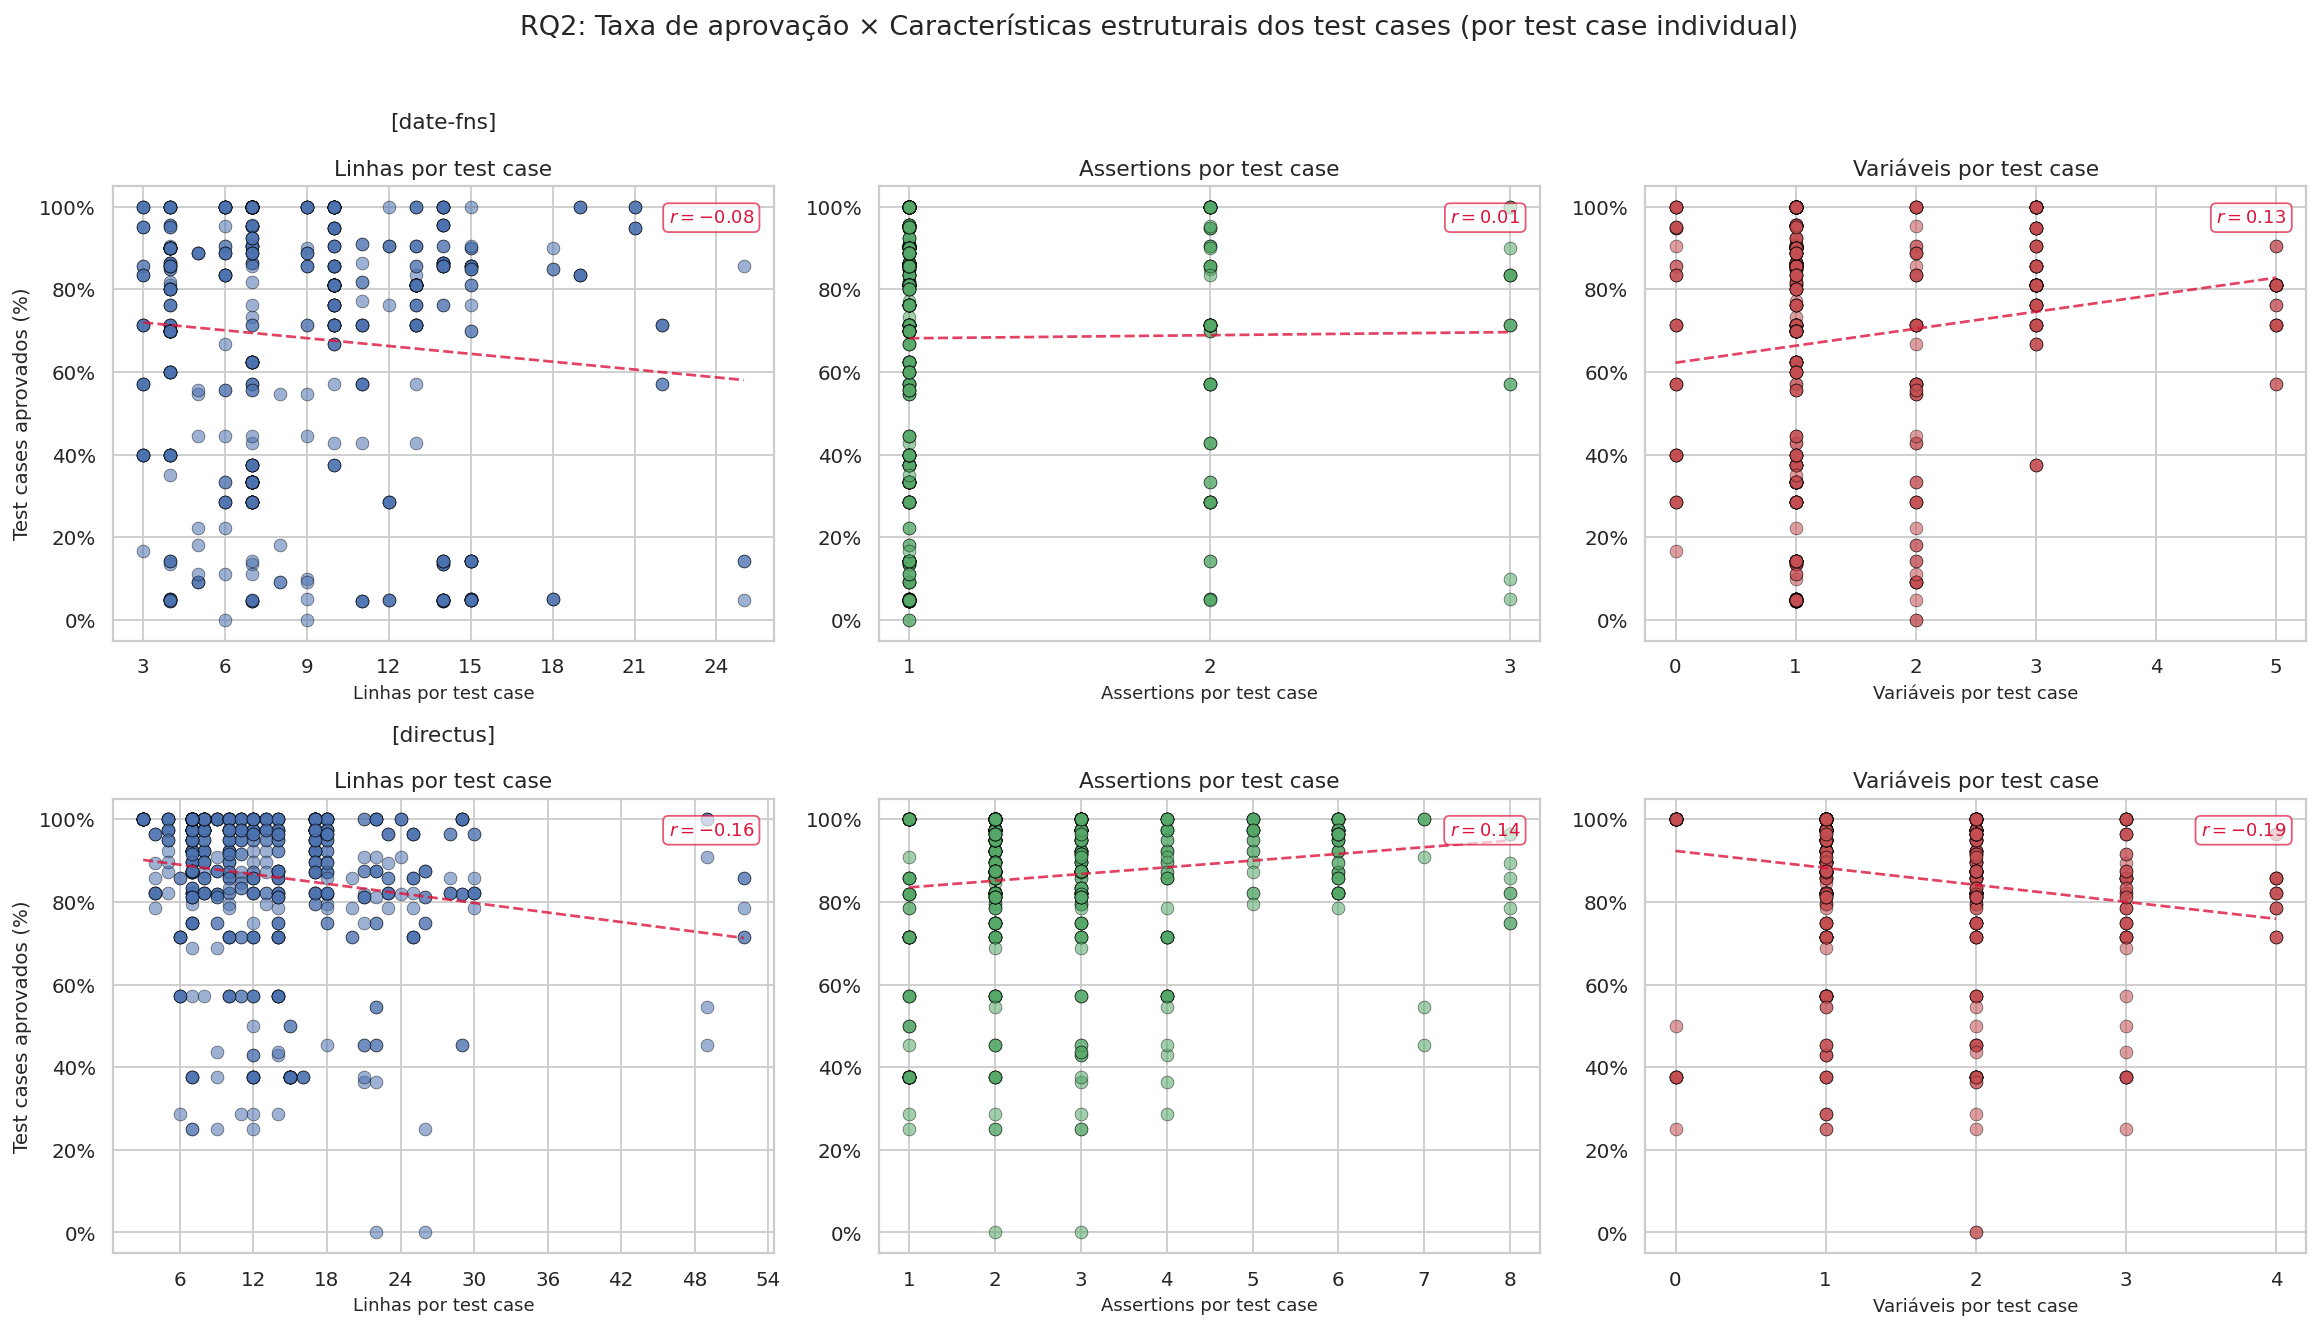

In [29]:
import re as _re

def extract_per_testcase_metrics(prompt_json):
    try:
        prompt = json.loads(prompt_json)
    except Exception:
        prompt = prompt_json
    text = prompt if isinstance(prompt, str) else str(prompt)
    test_blocks = _re.findall(r"## relevant-test-case.*?```\w*\n(.*?)```", text, _re.DOTALL)
    if not test_blocks:
        return [{"lines": 0, "assertions": 0, "vars": 0}]
    return [
        {
            "lines":      block.strip().count("\n") + 1,
            "assertions": len(_re.findall(r"\bexpect\(|\bassert\b|\bshould\b", block)),
            "vars":       len(_re.findall(r"\bconst\b|\blet\b|\bvar\b", block)),
        }
        for block in test_blocks
    ]

scatter_df = df[df["contextType"] == "permuted-relevant-test-case"].copy().reset_index(drop=True)

scatter_df["per_tc"] = scatter_df["modelUserPrompt"].apply(extract_per_testcase_metrics)
scatter_df = scatter_df.explode("per_tc").reset_index(drop=True)
scatter_df = scatter_df[scatter_df["per_tc"].notna()].copy()
scatter_df["tc_lines"]      = scatter_df["per_tc"].apply(lambda d: d["lines"] if isinstance(d, dict) else np.nan)
scatter_df["tc_assertions"] = scatter_df["per_tc"].apply(lambda d: d["assertions"] if isinstance(d, dict) else np.nan)
scatter_df["tc_vars"]       = scatter_df["per_tc"].apply(lambda d: d["vars"] if isinstance(d, dict) else np.nan)
scatter_df = scatter_df.dropna(subset=["tc_lines", "tc_assertions", "tc_vars"])

scatter_configs = [
    ("tc_lines",      "Linhas por test case",     "#4C72B0"),
    ("tc_assertions", "Assertions por test case", "#55A868"),
    ("tc_vars",       "Variáveis por test case",  "#C44E52"),
]

repos_v2 = scatter_df["repositoryName"].unique()
fig, axes = plt.subplots(len(repos_v2), len(scatter_configs), figsize=(18, 5 * len(repos_v2)))

if len(repos_v2) == 1:
    axes = [axes]

for row_idx, repo in enumerate(repos_v2):
    d = scatter_df[scatter_df["repositoryName"] == repo]
    for col_idx, (metric_col, metric_label, color) in enumerate(scatter_configs):
        ax = axes[row_idx][col_idx]

        x_vals = d[metric_col].values
        y_vals = d["testCasePassRate"].values * 100

        ax.scatter(x_vals, y_vals, alpha=0.55, color=color, edgecolors="black", linewidths=0.4, s=50)

        if len(np.unique(x_vals)) > 1:
            z = np.polyfit(x_vals, y_vals, 1)
            p_line = np.poly1d(z)
            x_sorted = np.linspace(x_vals.min(), x_vals.max(), 200)
            ax.plot(x_sorted, p_line(x_sorted), "--", color="crimson", linewidth=1.5, alpha=0.8)
        
            r = np.corrcoef(x_vals, y_vals)[0, 1]

            ax.annotate(
                f"$r = {r:.2f}$",
                xy=(0.97, 0.95),
                xycoords="axes fraction",
                ha="right", va="top",
                fontsize=10,
                color="crimson",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="crimson", alpha=0.7),
            )

        repo_title = f"[{repo}]\n\n" if col_idx == 0 else ""
        ax.set_title(f"{repo_title}{metric_label}", fontsize=12)
        if col_idx == 0:
            ax.set_ylabel("Test cases aprovados (%)", fontsize=11)
        ax.set_xlabel(metric_label, fontsize=10)
        ax.set_ylim(-5, 105)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.xaxis.set_major_locator(mtick.MaxNLocator(integer=True))

plt.suptitle("RQ2: Taxa de aprovação × Características estruturais dos test cases (por test case individual)", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("figures/rq2_internal_structure_analysis_v2.png", bbox_inches="tight")
plt.show()

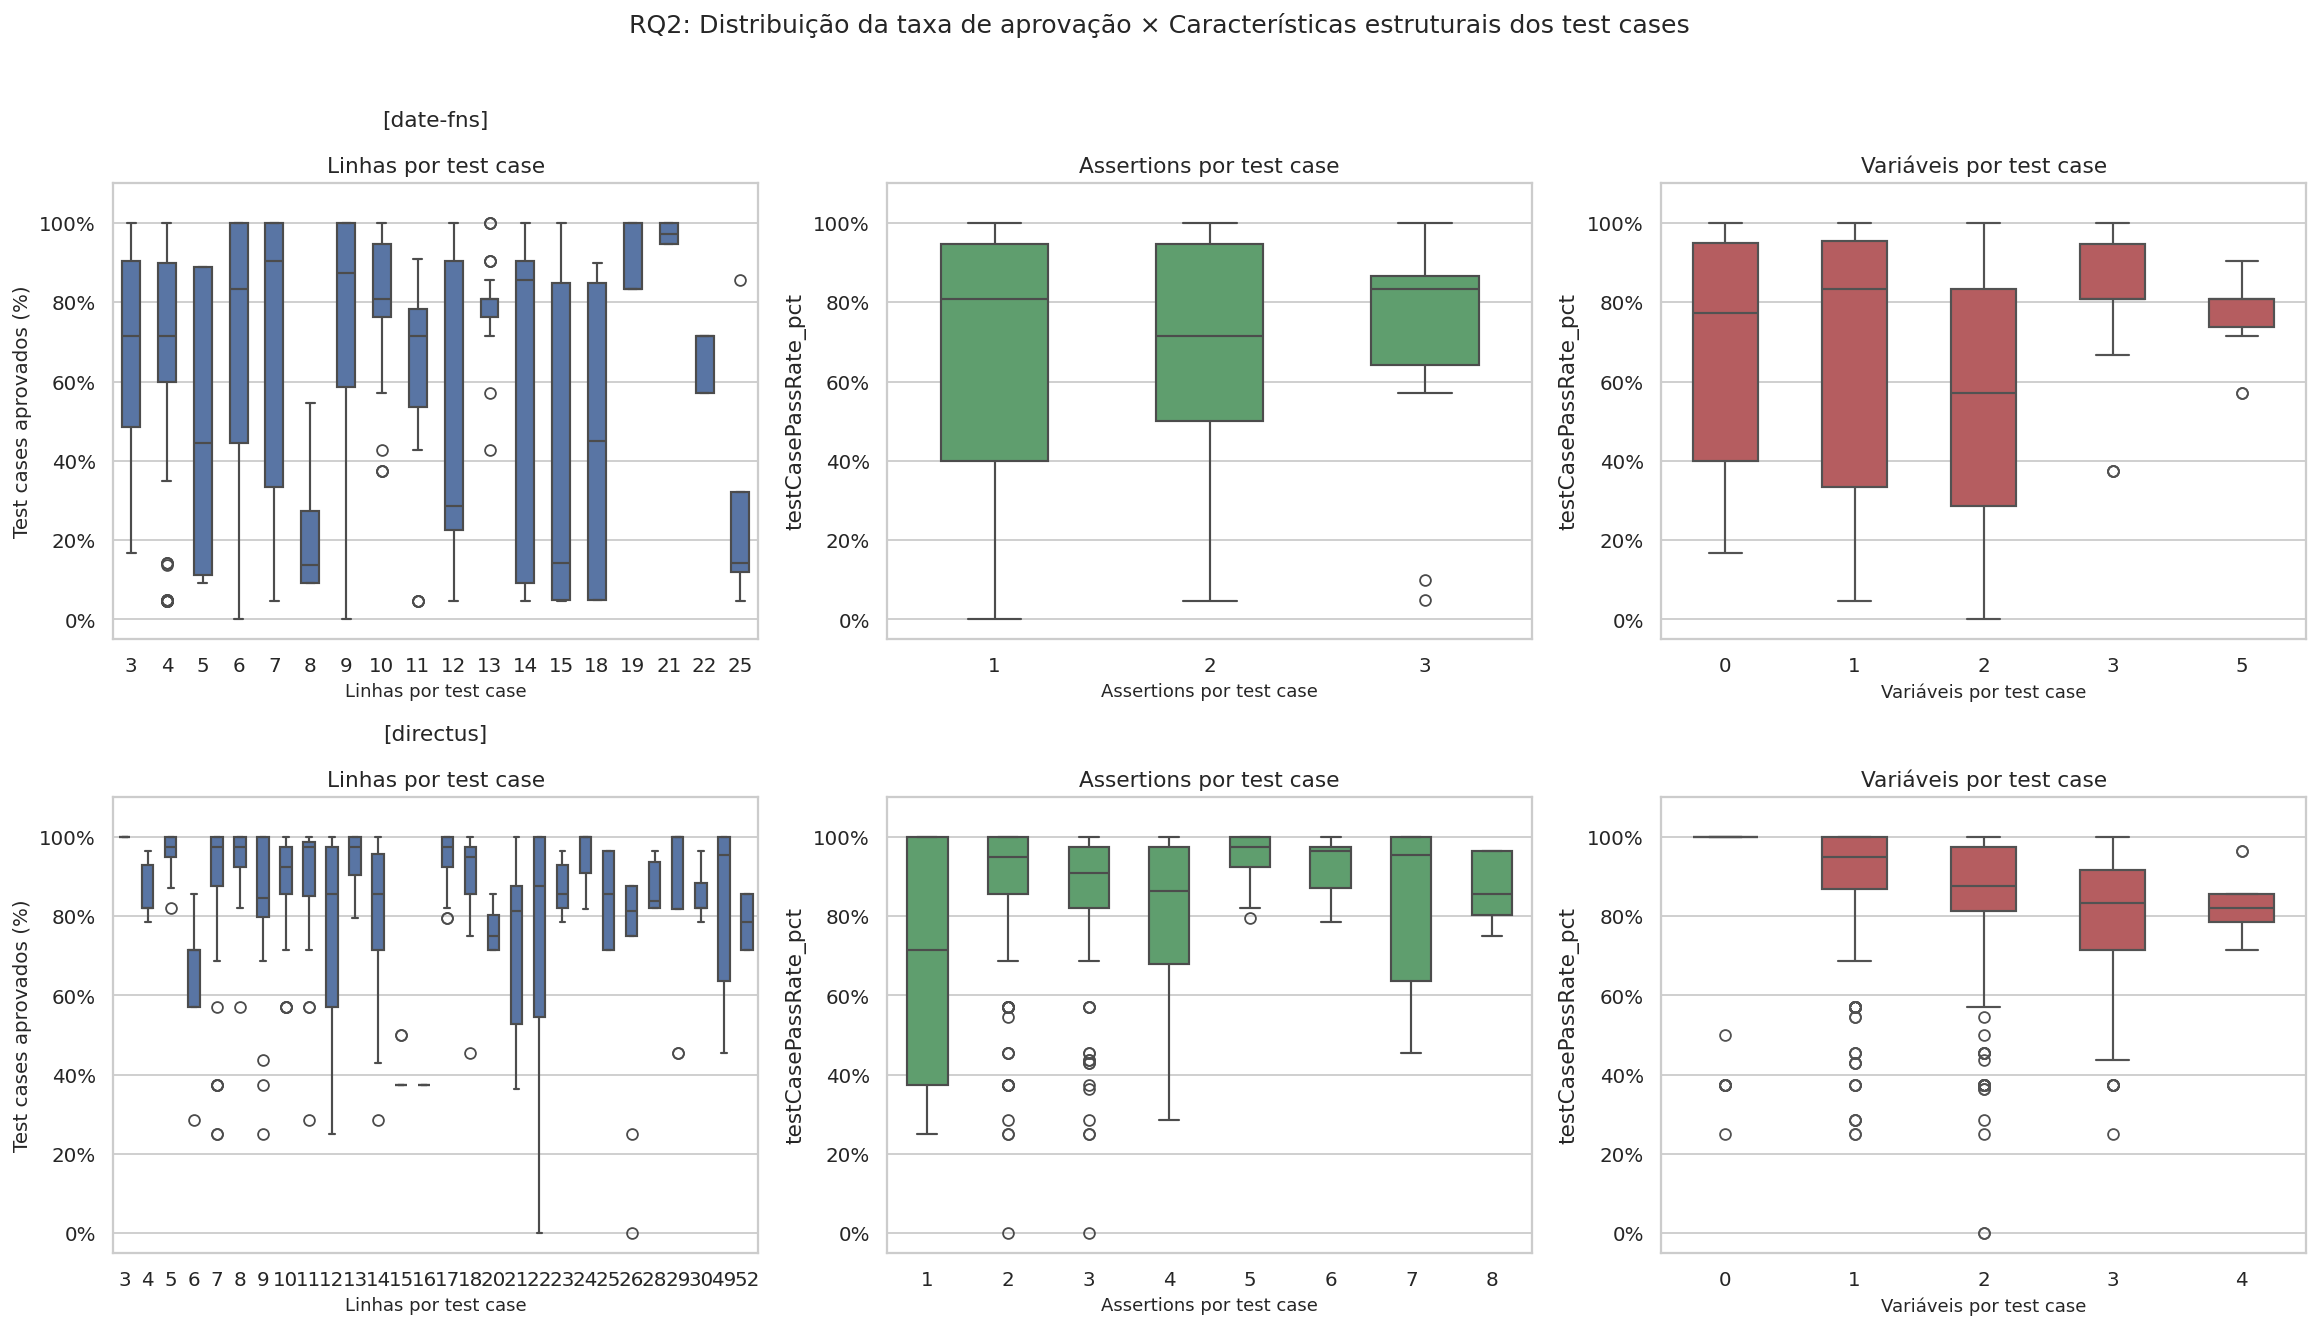

In [24]:
# RQ2: Boxplot de testCasePassRate × valor real da métrica (mesma base do scatterplot)
box_configs = [
    ("tc_lines",      "Linhas por test case",     "#4C72B0"),
    ("tc_assertions", "Assertions por test case", "#55A868"),
    ("tc_vars",       "Variáveis por test case",  "#C44E52"),
]

repos_box = scatter_df["repositoryName"].unique()
fig, axes = plt.subplots(len(repos_box), len(box_configs), figsize=(18, 5 * len(repos_box)))

if len(repos_box) == 1:
    axes = [axes]

for row_idx, repo in enumerate(repos_box):
    d = scatter_df[scatter_df["repositoryName"] == repo].copy()
    d["testCasePassRate_pct"] = d["testCasePassRate"] * 100
    for col_idx, (metric_col, metric_label, color) in enumerate(box_configs):
        ax = axes[row_idx][col_idx]
        order = sorted(d[metric_col].dropna().unique().astype(int))
        sns.boxplot(
            data=d,
            x=metric_col,
            y="testCasePassRate_pct",
            order=order,
            ax=ax,
            color=color,
            width=0.5,
            linewidth=1.2,
        )
        repo_title = f"[{repo}]\n\n" if col_idx == 0 else ""
        ax.set_title(f"{repo_title}{metric_label}", fontsize=12)
        if col_idx == 0:
            ax.set_ylabel("Test cases aprovados (%)", fontsize=11)
        ax.set_xlabel(metric_label, fontsize=10)
        ax.set_ylim(-5, 110)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle("RQ2: Distribuição da taxa de aprovação × Características estruturais dos test cases", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("figures/rq2_boxplot_structure_v2.png", bbox_inches="tight")
plt.show()

## RQ3: Quais LLMs geram métodos de forma mais eficiente?

### Gráfico: Distribuição da taxa de aprovação por modelo × Quantidade de testes no contexto

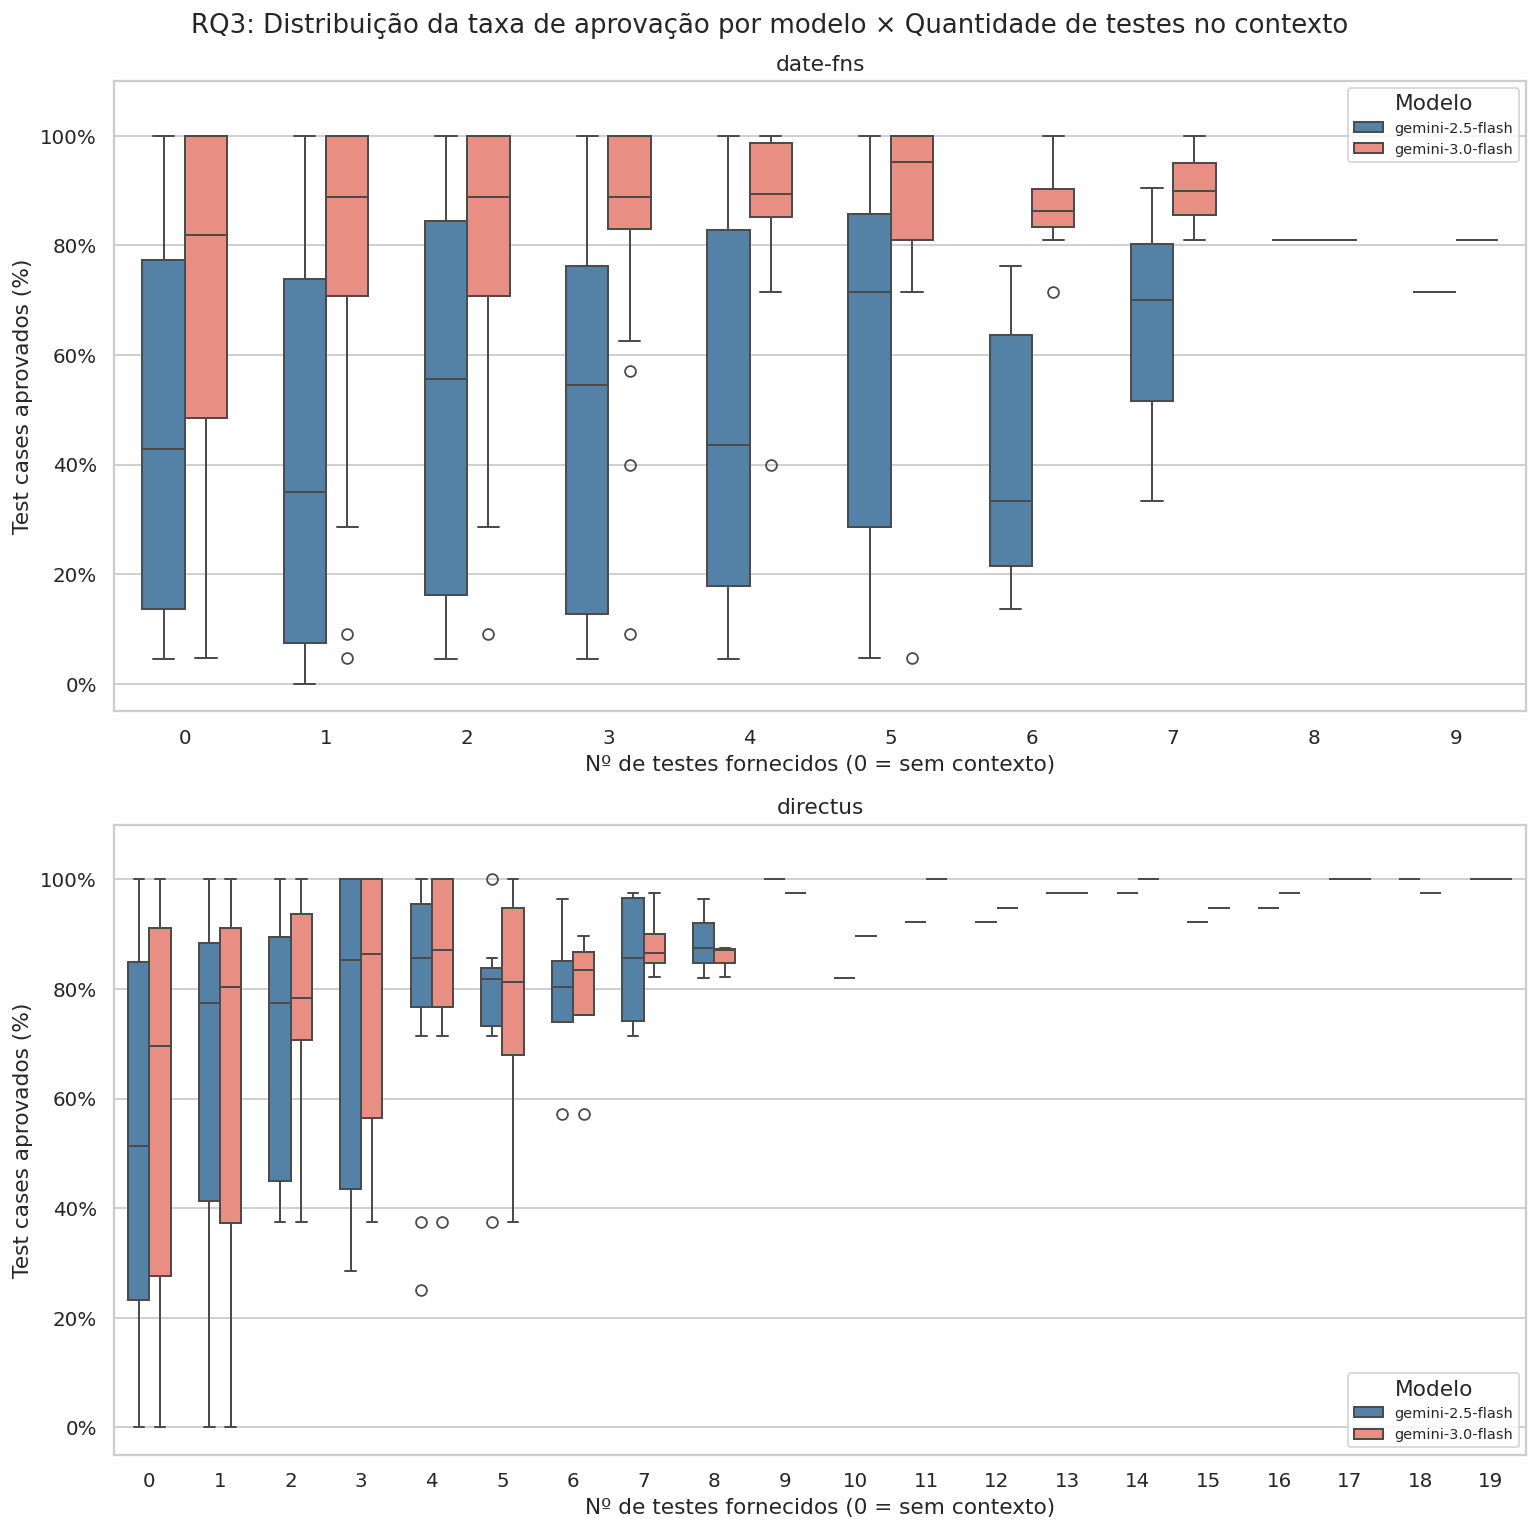

In [25]:
baseline_rq3 = df[df["contextType"] == "no-relevant-test-case"].copy()
baseline_rq3["experimentContextItemCount"] = 0
permuted_rq3 = df[df["contextType"] == "permuted-relevant-test-case"].copy()
combined_rq3 = pd.concat([baseline_rq3, permuted_rq3], ignore_index=True)
combined_rq3["testCasePassRate_pct"] = combined_rq3["testCasePassRate"].astype(float) * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 12))

model_palette = {
    "gemini-2.5-flash": "steelblue",
    "gemini-3.0-flash": "salmon",
}

for ax, repo in zip(axes, df["repositoryName"].unique()):
    d = combined_rq3[combined_rq3["repositoryName"] == repo]
    order = sorted(d["experimentContextItemCount"].unique())

    sns.boxplot(
        data=d,
        x="experimentContextItemCount",
        y="testCasePassRate_pct",
        hue="modelName",
        order=order,
        ax=ax,
        width=0.6,
        linewidth=1.1,
        palette=model_palette,
    )

    ax.set_title(f"{repo}")
    ax.set_xlabel("Nº de testes fornecidos (0 = sem contexto)")
    ax.set_ylabel("Test cases aprovados (%)")
    ax.set_ylim(-5, 110)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title="Modelo", fontsize=8)

plt.suptitle("RQ3: Distribuição da taxa de aprovação por modelo × Quantidade de testes no contexto")
plt.tight_layout()
plt.savefig("figures/rq3_model_test_count_curve_v2.png", bbox_inches="tight")
plt.show()

### Gráfico: Distribuição da compilabilidade por modelo × Quantidade de testes no contexto

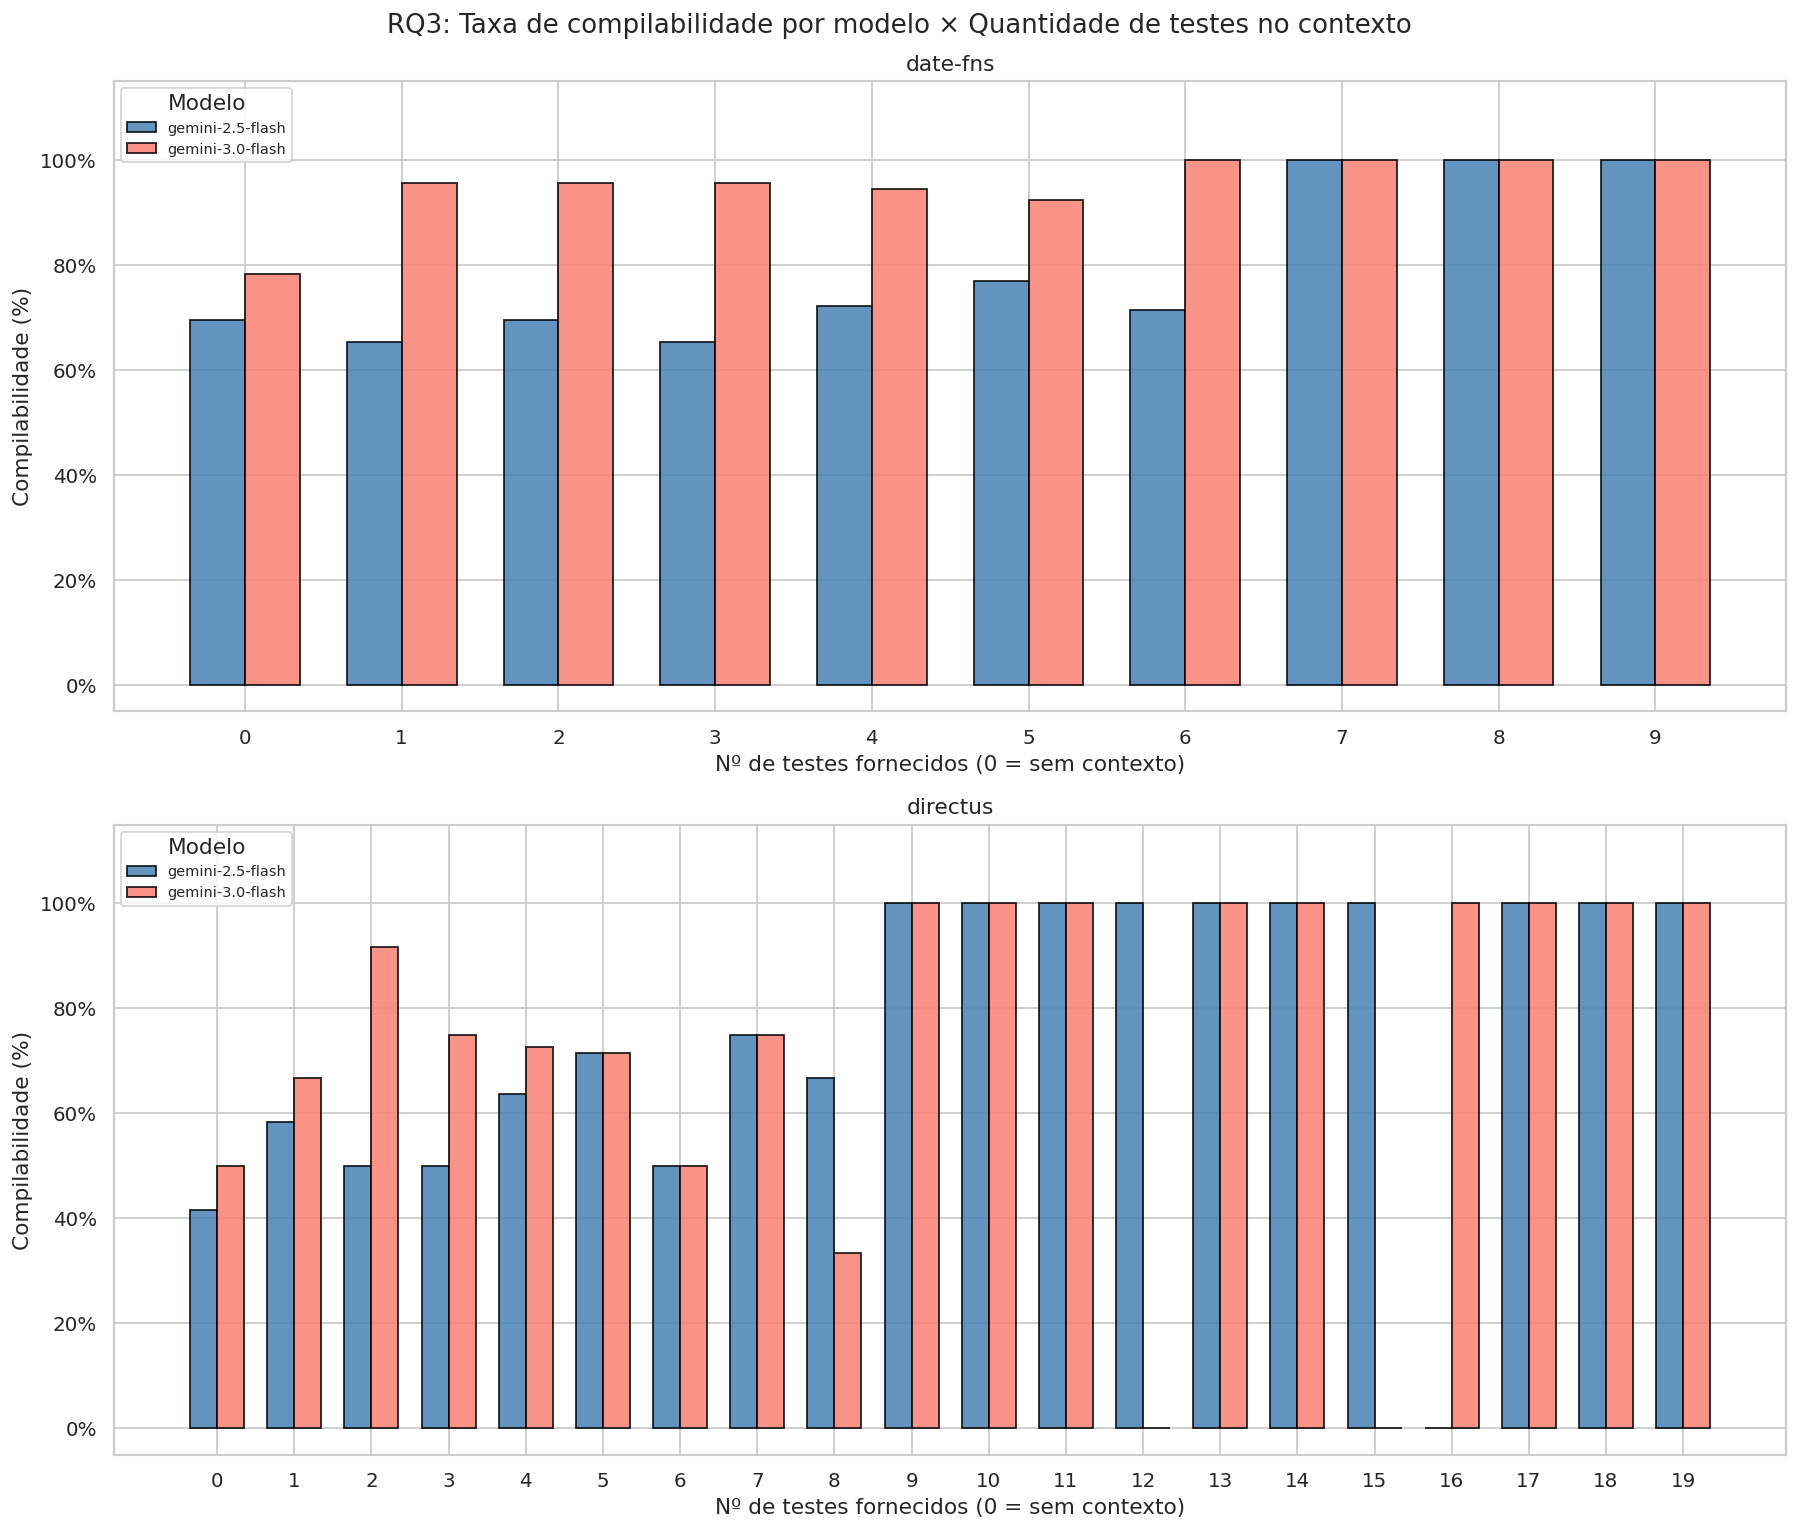

In [26]:
baseline_comp = df[df["contextType"] == "no-relevant-test-case"].copy()
baseline_comp["experimentContextItemCount"] = 0
permuted_comp = df[df["contextType"] == "permuted-relevant-test-case"].copy()
combined_comp = pd.concat([baseline_comp, permuted_comp], ignore_index=True)

comp_means = (
    combined_comp
    .groupby(["repositoryName", "experimentContextItemCount", "modelName"])["isModelResultCompilable"]
    .mean()
    .reset_index()
)

model_palette = {
    "gemini-2.5-flash": "steelblue",
    "gemini-3.0-flash": "salmon",
}

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharey=True)

for ax, repo in zip(axes, df["repositoryName"].unique()):
    d = comp_means[comp_means["repositoryName"] == repo]
    order = sorted(d["experimentContextItemCount"].unique())
    models_list = sorted(d["modelName"].unique())
    x = np.arange(len(order))
    width = 0.35

    for i, model in enumerate(models_list):
        dm = (
            d[d["modelName"] == model]
            .set_index("experimentContextItemCount")["isModelResultCompilable"]
            .reindex(order, fill_value=0)
        )
        bars = ax.bar(
            x + i * width,
            dm.values * 100,
            width,
            label=model,
            color=model_palette.get(model, None),
            edgecolor="black",
            alpha=0.85,
        )

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([str(v) for v in order])
    ax.set_title(f"{repo}")
    ax.set_xlabel("Nº de testes fornecidos (0 = sem contexto)")
    ax.set_ylabel("Compilabilidade (%)")
    ax.set_ylim(-5, 115)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title="Modelo", fontsize=8)

plt.suptitle("RQ3: Taxa de compilabilidade por modelo × Quantidade de testes no contexto")
plt.tight_layout()
plt.savefig("figures/rq3_compilability_by_model_v2.png", bbox_inches="tight")
plt.show()

### Gráfico: Divergência de desempenho entre modelos por experimento

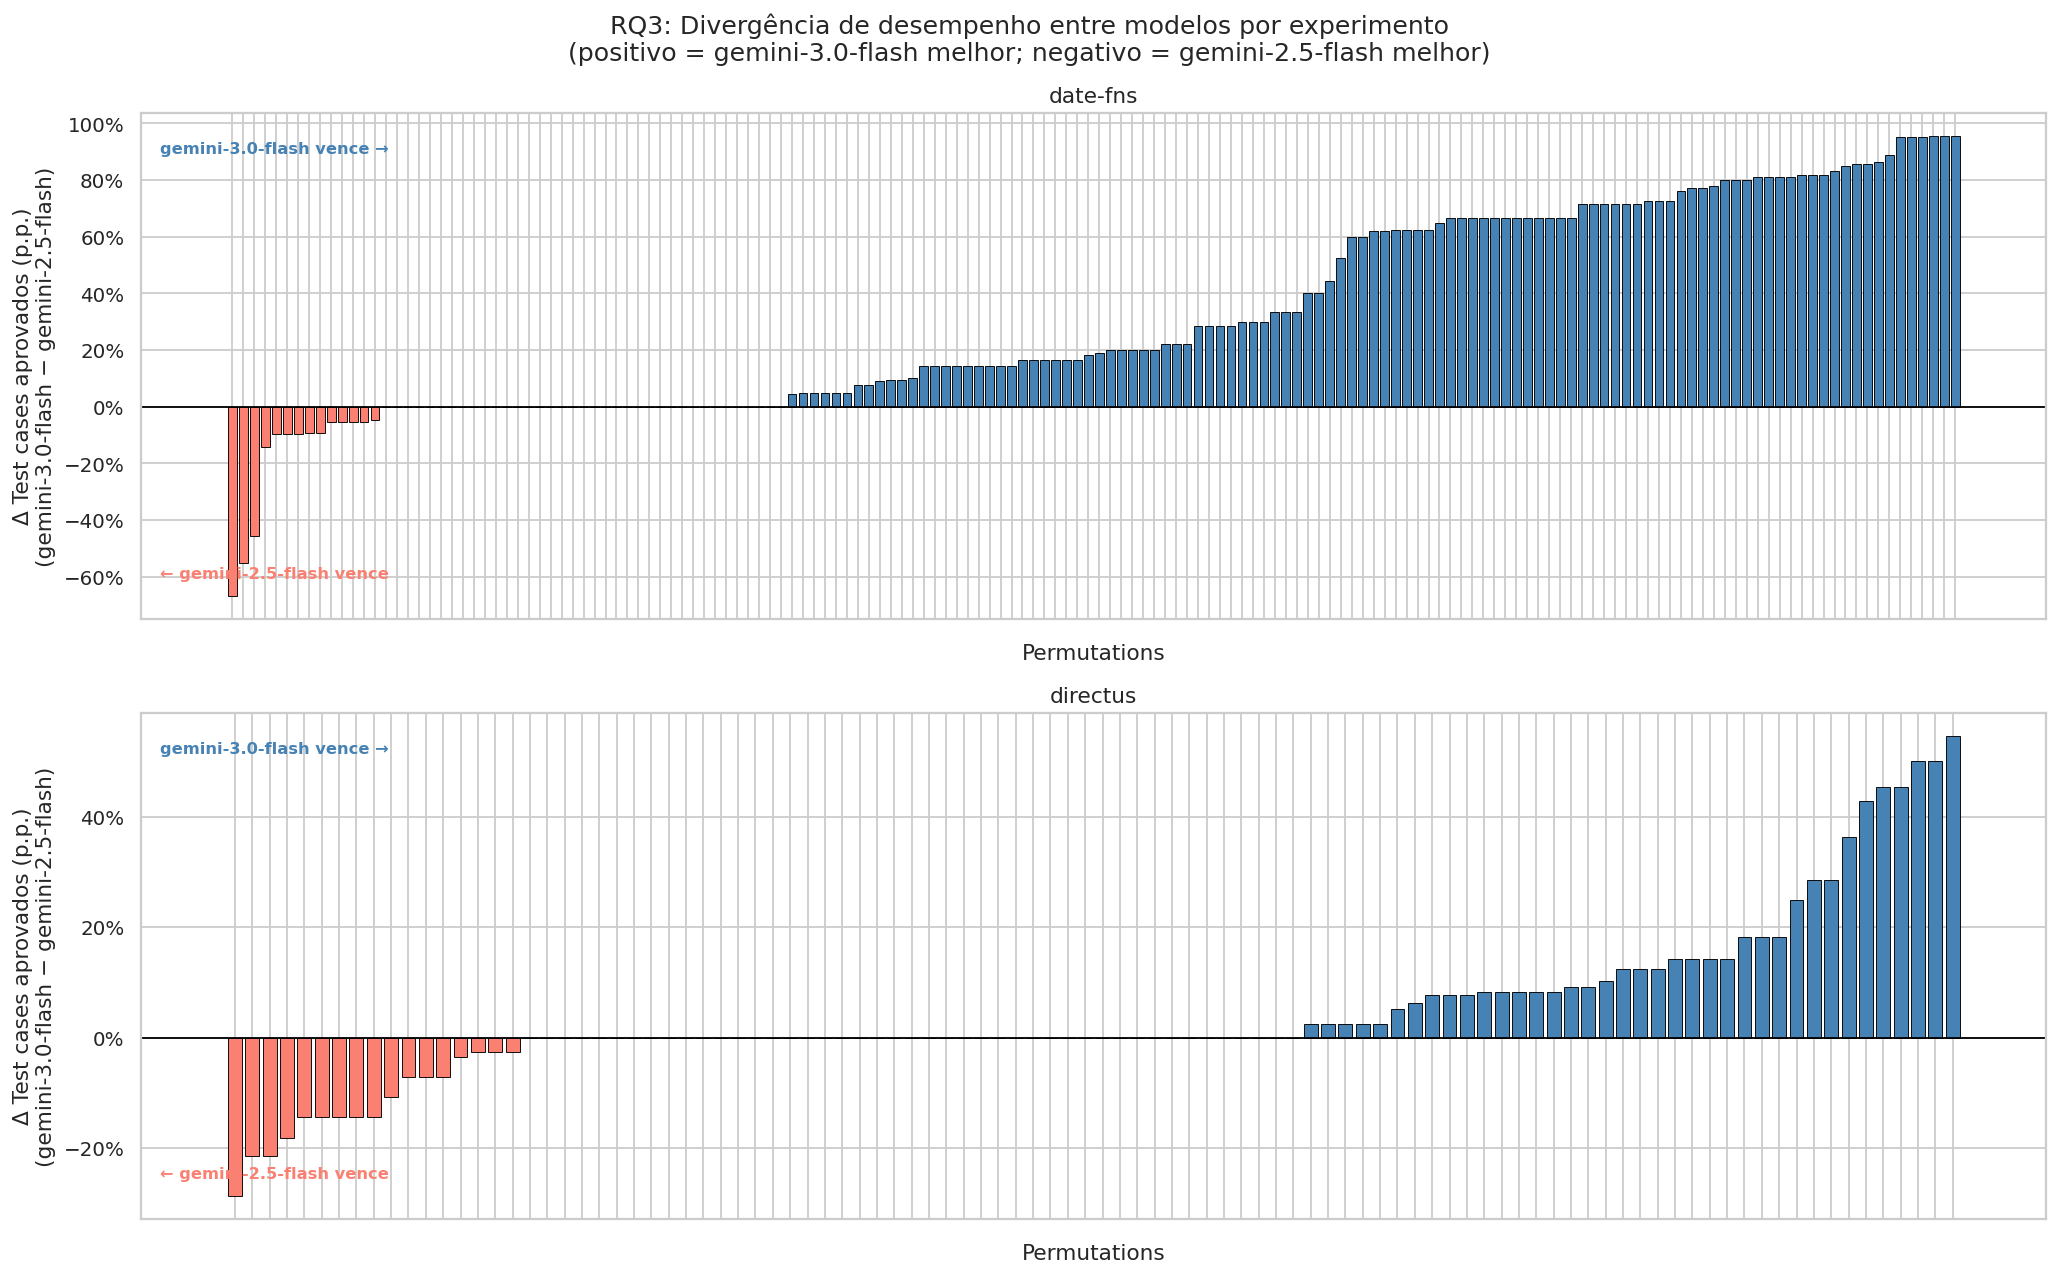

In [27]:
models_v2 = df["modelName"].unique()
if len(models_v2) != 2:
    print("Essa análise requer exatamente 2 modelos no dataset.")
else:
    m0_v2, m1_v2 = models_v2[0], models_v2[1]

    left_v2 = df[df["modelName"] == m0_v2][[
        "repositoryName", "methodName", "contextType",
        "experimentContextItemCount", "testCasePassRate",
    ]]
    right_v2 = df[df["modelName"] == m1_v2][[
        "repositoryName", "methodName", "contextType",
        "experimentContextItemCount", "testCasePassRate",
    ]]
    paired_v2 = left_v2.merge(
        right_v2,
        on=["repositoryName", "methodName", "contextType", "experimentContextItemCount"],
        suffixes=(f"_{m0_v2}", f"_{m1_v2}"),
    )
    paired_v2["delta"] = (
        paired_v2[f"testCasePassRate_{m1_v2}"] - paired_v2[f"testCasePassRate_{m0_v2}"]
    ) * 100
    paired_v2["run_label"] = "N=" + paired_v2["experimentContextItemCount"].astype(str)

    repos_div = paired_v2["repositoryName"].unique()
    fig, axes = plt.subplots(len(repos_div), 1, figsize=(16, 5 * len(repos_div)))

    if len(repos_div) == 1:
        axes = [axes]

    for ax, repo in zip(axes, repos_div):
        d = paired_v2[paired_v2["repositoryName"] == repo].sort_values("delta").reset_index(drop=True)
        bar_colors = ["steelblue" if v >= 0 else "salmon" for v in d["delta"]]

        ax.bar(range(len(d)), d["delta"], color=bar_colors, edgecolor="black", linewidth=0.5)
        ax.axhline(0, color="black", linewidth=1.0)

        ax.set_xticks(range(len(d)))
        ax.set_xticklabels([], fontsize=8)
        ax.set_ylabel(f"Δ Test cases aprovados (p.p.)\n({m1_v2} − {m0_v2})")
        ax.set_title(f"{repo}")
        ax.set_xlabel("Permutations")
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())

        ax.annotate(f"← {m0_v2} vence", xy=(0.01, 0.08), xycoords="axes fraction",
                    color="salmon", fontsize=9, fontweight="bold")
        ax.annotate(f"{m1_v2} vence →", xy=(0.01, 0.92), xycoords="axes fraction",
                    color="steelblue", fontsize=9, fontweight="bold")

    plt.suptitle(
        f"RQ3: Divergência de desempenho entre modelos por experimento\n"
        f"(positivo = {m1_v2} melhor; negativo = {m0_v2} melhor)",
        fontsize=14,
    )
    plt.tight_layout()
    plt.savefig("figures/rq3_divergence_v2.png", bbox_inches="tight")
    plt.show()